In [41]:
import ast
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


In [42]:
PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == "results" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data_helpers.corpus import build_merged_corpus

In [43]:
# Input paths and selected columns are defined in dataset_config.merged_corpus.

In [44]:
corpus_df = build_merged_corpus()

In [45]:
print(f"corpus_df shape: {corpus_df.shape}")
display(corpus_df.head())


corpus_df shape: (605199, 30)


,UT,title,authors,abstract,source,publication_year,wos_categories,doi,eligibility,s1_r,...,pred_subregions,pred_countries,locales,locale_coordinates,realm,pred_study_design,pred_methods_data_collection,pred_methods_analysis,pred_has_comparison,pred_comparison_types
0,WOS:001410940900001,Skeletal deformities in Sparus aurata from Tür...,"[""Güclü, SS"", ""Jawad, LA"", ""Koca, HU"", ""Cilbiz...",The first record of the abnormalities ankylosi...,WILEY,2026,"[""Anatomy & Morphology"", ""Zoology""]",10.1111/azo.12538,ELIGIBLE,1,...,"[""Western Asia""]","[""TUR""]","[""Bafa Lake"", ""Bodrum Coast (Aegean Sea)"", ""Ae...",[],"[""Freshwater-Marine""]",Observational,"[""FieldSurvey"", ""SpecimenRecords_Herbarium_Mus...","[""Unclear""]",False,[]
1,WOS:001498294300001,Size-dependent effects of oxo-degradable plast...,"[""Thanh, DK"", ""Brown, RW"", ""Graf, M"", ""Reay, M...",Agricultural plastic mulch film represents a s...,HIGHER EDUCATION PRESS,2026,"[""Agronomy""]",10.15302/J-FASE-2025623,ELIGIBLE,1,...,"[""North America""]","[""Not Applicable""]","[""Not Applicable""]",[],"[""Terrestrial""]",Experimental,"[""Mesocosm"", ""LabAssay""]","[""DiversityMetrics"", ""CommunityComposition_Mul...",True,"[""ControlImpact""]"
2,WOS:001501498700001,Traditional and biodegradable plastics improve...,"[""Wu, JL"", ""Liu, YH"", ""Wang, L"", ""Xiao, ML"", ""...",Microplastic accumulation caused by traditiona...,HIGHER EDUCATION PRESS,2026,"[""Agronomy""]",10.15302/J-FASE-2025626,ELIGIBLE,1,...,"[""Caribbean""]","[""Not Applicable""]","[""Not Applicable""]",[],"[""Terrestrial""]",Experimental,"[""Mesocosm""]","[""GLM_GLM_MixedEffects"", ""CommunityComposition...",True,"[""ControlImpact"", ""TreatedUntreated""]"
3,WOS:001509397300001,Adapt or perish? Flexible habitat selection by...,"[""Nicola, GG"", ""Ayllón, D"", ""Almodóvar, A"", ""E...",Mediterranean freshwaters are renowned for the...,SPRINGER,2026,"[""Marine & Freshwater Biology""]",10.1007/s10750-025-05917-y,ELIGIBLE,1,...,"[""Central and Western Europe""]",[],[],[],"[""Freshwater""]",Observational,"[""FieldSurvey""]","[""Other:KruskalWallis_GAM""]",True,"[""PresenceAbsence"", ""Other""]"
4,WOS:001509429700001,Effects of flooding on aquatic macroinvertebra...,"[""Wooden, PLS"", ""Kelso, WE"", ""Kaller, MD""]",The Atchafalaya River Basin is the largest con...,SPRINGER,2026,"[""Marine & Freshwater Biology""]",10.1007/s10750-025-05921-2,ELIGIBLE,1,...,"[""North America""]","[""USA""]","[""Atchafalaya River Basin (Louisiana)""]",[],"[""Freshwater""]",Observational,"[""FieldSurvey""]","[""DiversityMetrics"", ""CommunityComposition_Mul...",True,"[""SpatialGradient_NearFar_UpDownstream""]"


In [46]:
bio_loss_df = corpus_df.loc[corpus_df["s2_dir"].eq("negative")].copy()

print(f"bio_loss_df shape: {bio_loss_df.shape}")
display(bio_loss_df.head())


bio_loss_df shape: (253081, 30)


,UT,title,authors,abstract,source,publication_year,wos_categories,doi,eligibility,s1_r,...,pred_subregions,pred_countries,locales,locale_coordinates,realm,pred_study_design,pred_methods_data_collection,pred_methods_analysis,pred_has_comparison,pred_comparison_types
1,WOS:001498294300001,Size-dependent effects of oxo-degradable plast...,"[""Thanh, DK"", ""Brown, RW"", ""Graf, M"", ""Reay, M...",Agricultural plastic mulch film represents a s...,HIGHER EDUCATION PRESS,2026,"[""Agronomy""]",10.15302/J-FASE-2025623,ELIGIBLE,1,...,"[""North America""]","[""Not Applicable""]","[""Not Applicable""]",[],"[""Terrestrial""]",Experimental,"[""Mesocosm"", ""LabAssay""]","[""DiversityMetrics"", ""CommunityComposition_Mul...",True,"[""ControlImpact""]"
4,WOS:001509429700001,Effects of flooding on aquatic macroinvertebra...,"[""Wooden, PLS"", ""Kelso, WE"", ""Kaller, MD""]",The Atchafalaya River Basin is the largest con...,SPRINGER,2026,"[""Marine & Freshwater Biology""]",10.1007/s10750-025-05921-2,ELIGIBLE,1,...,"[""North America""]","[""USA""]","[""Atchafalaya River Basin (Louisiana)""]",[],"[""Freshwater""]",Observational,"[""FieldSurvey""]","[""DiversityMetrics"", ""CommunityComposition_Mul...",True,"[""SpatialGradient_NearFar_UpDownstream""]"
5,WOS:001510635100001,Minimizing Heavy Metal Contamination in Mining...,"[""Ganesh, CR"", ""Rao, KR"", ""Sumalatha, J"", ""Sre...",The foremost environmental challenge the world...,TAYLOR & FRANCIS INC,2026,"[""Environmental Sciences""]",10.1080/15320383.2025.2518147,ELIGIBLE,1,...,"[""North America""]","[""Not Applicable""]","[""Not Applicable""]",[],"[""Terrestrial""]",Experimental,"[""LabAssay""]","[""Other: ANOVA""]",True,"[""Other""]"
6,WOS:001512577600001,Physicochemical Characteristics and Potentiall...,"[""Kirana, KH"", ""Iman, MRR"", ""Shafaria, M"", ""Ag...",The midstream of the Citarum River is vital to...,TAYLOR & FRANCIS INC,2026,"[""Environmental Sciences""]",10.1080/15320383.2025.2519758,ELIGIBLE,1,...,"[""South-East Asia""]","[""IDN""]","[""Citarum River midstream"", ""Saguling Hydroele...",[],"[""Freshwater""]",Observational,[],"[""Other:StatisticalCorrelation""]",False,[]
12,WOS:001522363900001,Impacts of present heat waves in freshwater en...,"[""Riesco, MF"", ""Calvo-Rodríguez, L"", ""Esteban,...",Extreme temperature events are urgent concerns...,ELSEVIER,2026,"[""Fisheries"", ""Marine & Freshwater Biology""]",10.1016/j.aquaculture.2025.742879,ELIGIBLE,-1,...,"[""Central and Western Europe""]","[""ESP""]","[""Castilla y León""]",[],"[""Freshwater""]",Experimental,"[""FieldSurvey"", ""LabAssay""]","[""GLM_GLM_MixedEffects"", ""Other: Statistical c...",True,"[""TreatedUntreated""]"


In [65]:
bio_loss_df[:1000].to_csv('sample_bio_loss_df.csv', index=False)

In [47]:
BIODIVERSITY = {
    "primary": "#2E7D32",
    "context": "#B8CDB2",
    "pale": "#DCEAD7",
    "eligible": "#67A84B",
    "ineligible": "#D95F5F",
    "unclear": "#C49A00",
    "screening": "#6F91C7",
    "ink": "#2B2B2B",
    "neutral": "#D9D9D9",
    "paper": "#FFFFFF",
}

OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#000000"]

plt.rcParams.update(
    {
        "figure.facecolor": BIODIVERSITY["paper"],
        "axes.facecolor": BIODIVERSITY["paper"],
        "axes.edgecolor": BIODIVERSITY["neutral"],
        "axes.labelcolor": BIODIVERSITY["ink"],
        "axes.titlecolor": BIODIVERSITY["ink"],
        "xtick.color": BIODIVERSITY["ink"],
        "ytick.color": BIODIVERSITY["ink"],
        "font.family": "sans-serif",
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)


def parse_label_list(value) -> list[str]:
    if isinstance(value, list):
        raw_items = value
    elif pd.isna(value):
        raw_items = []
    else:
        text = str(value).strip()
        if not text or text.lower() in {"nan", "none", "null"} or text == "[]":
            raw_items = []
        elif text.startswith("[") and text.endswith("]"):
            raw_items = None
            for parser in (json.loads, ast.literal_eval):
                try:
                    parsed = parser(text)
                except (SyntaxError, ValueError, TypeError, json.JSONDecodeError):
                    continue
                if isinstance(parsed, list):
                    raw_items = parsed
                    break
            if raw_items is None:
                raw_items = [text]
        elif ";" in text:
            raw_items = text.split(";")
        else:
            raw_items = [text]

    labels = []
    seen = set()
    for item in raw_items:
        if pd.isna(item):
            continue
        label = str(item).strip()
        if label and label not in seen:
            labels.append(label)
            seen.add(label)
    return labels


def exploded_labels(df: pd.DataFrame, label_col: str, year_col: str = "publication_year") -> pd.DataFrame:
    out = df[["UT", year_col, label_col]].copy()
    out[year_col] = pd.to_numeric(out[year_col], errors="coerce").astype("Int64")
    out["label"] = out[label_col].map(parse_label_list)
    out["label_count"] = out["label"].map(len)
    out = out.explode("label").dropna(subset=[year_col, "label"])
    out["label"] = out["label"].astype("string").str.strip()
    return out.loc[out["label"].ne("")]


def label_counts(df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    return (
        exploded_labels(df, label_col)
        .groupby("label", observed=True)
        .agg(records=("UT", "nunique"), assignments=("UT", "size"))
        .reset_index()
        .sort_values(["records", "label"], ascending=[False, True], ignore_index=True)
    )


def label_counts_by_year(df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    return (
        exploded_labels(df, label_col)
        .groupby(["publication_year", "label"], observed=True)
        .agg(records=("UT", "nunique"), assignments=("UT", "size"))
        .reset_index()
        .sort_values(["publication_year", "records", "label"], ascending=[True, False, True], ignore_index=True)
    )


def format_count(value: int | float) -> str:
    value = int(value)
    if value >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    if value >= 10_000:
        return f"{value / 1_000:.0f}k"
    if value >= 1_000:
        return f"{value / 1_000:.1f}k"
    return str(value)


def style_axis(ax, grid_axis: str | None = "x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(BIODIVERSITY["neutral"])
    ax.spines["bottom"].set_color(BIODIVERSITY["neutral"])
    ax.tick_params(length=0)
    if grid_axis:
        ax.grid(axis=grid_axis, color=BIODIVERSITY["neutral"], linewidth=0.6, alpha=0.45)
    ax.set_axisbelow(True)


def color_map_for_labels(labels: list[str]) -> dict[str, str]:
    colors = list(plt.get_cmap("tab20").colors)
    hex_colors = ["#%02x%02x%02x" % tuple(int(channel * 255) for channel in color[:3]) for color in colors]
    preferred = OKABE_ITO + [color for color in hex_colors if color not in OKABE_ITO]
    return {label: preferred[i % len(preferred)] for i, label in enumerate(labels)}


def plot_publication_year_counts(df: pd.DataFrame, title: str) -> pd.DataFrame:
    counts = (
        pd.to_numeric(df["publication_year"], errors="coerce")
        .dropna()
        .astype(int)
        .value_counts()
        .sort_index()
        .rename_axis("publication_year")
        .reset_index(name="records")
    )

    fig, ax = plt.subplots(figsize=(11, 3.8))
    ax.bar(counts["publication_year"].astype(str), counts["records"], color=BIODIVERSITY["primary"], width=0.82)
    ax.set_title(title, loc="left")
    ax.set_xlabel("Publication year")
    ax.set_ylabel("Records")
    ax.yaxis.set_major_formatter(lambda x, _: format_count(x))
    ax.tick_params(axis="x", labelrotation=90)
    style_axis(ax, "y")
    plt.tight_layout()
    plt.show()
    return counts


def plot_label_distribution(df: pd.DataFrame, label_col: str, top_n: int | None = 15) -> pd.DataFrame:
    counts = label_counts(df, label_col)
    plot_counts = counts.head(top_n).sort_values("records", ascending=True) if top_n else counts.sort_values("records", ascending=True)
    label_colors = color_map_for_labels(counts["label"].tolist())
    colors = [label_colors[label] for label in plot_counts["label"]]

    fig, ax = plt.subplots(figsize=(9.5, max(3.2, 0.34 * len(plot_counts))))
    ax.hlines(y=plot_counts["label"], xmin=0, xmax=plot_counts["records"], color=BIODIVERSITY["neutral"], linewidth=1)
    ax.scatter(plot_counts["records"], plot_counts["label"], color=colors, s=46, zorder=3)
    x_max = plot_counts["records"].max()
    for _, row in plot_counts.iterrows():
        ax.text(row["records"] + x_max * 0.012, row["label"], format_count(row["records"]), va="center", fontsize=9, color=BIODIVERSITY["ink"])
    ax.set_xlim(0, x_max * 1.16)
    ax.set_title(f"{label_col}: record-label assignments", loc="left")
    ax.set_xlabel("Records")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(lambda x, _: format_count(x))
    style_axis(ax, "x")
    plt.tight_layout()
    plt.show()
    return counts


def plot_label_distribution_by_year(df: pd.DataFrame, label_col: str, top_n: int | None = None) -> pd.DataFrame:
    counts = label_counts_by_year(df, label_col)
    labels = label_counts(df, label_col)["label"].tolist()
    if top_n:
        labels = labels[:top_n]
    label_colors = color_map_for_labels(labels)

    plot_counts = counts.loc[counts["label"].isin(labels)]
    pivot = plot_counts.pivot_table(
        index="publication_year",
        columns="label",
        values="records",
        fill_value=0,
        aggfunc="sum",
    ).reindex(columns=labels, fill_value=0)

    fig, ax = plt.subplots(figsize=(13, 5.2))
    bottom = pd.Series(0, index=pivot.index)
    for label in labels:
        ax.bar(
            pivot.index.astype(str),
            pivot[label],
            bottom=bottom,
            label=label,
            color=label_colors[label],
            width=0.84,
        )
        bottom = bottom + pivot[label]

    ax.set_title(f"{label_col}: records by publication year", loc="left")
    ax.set_xlabel("Publication year")
    ax.set_ylabel("Record-label assignments")
    ax.yaxis.set_major_formatter(lambda x, _: format_count(x))
    ax.tick_params(axis="x", labelrotation=90)
    ax.legend(title=label_col, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
    style_axis(ax, "y")
    plt.tight_layout()
    plt.show()
    return counts


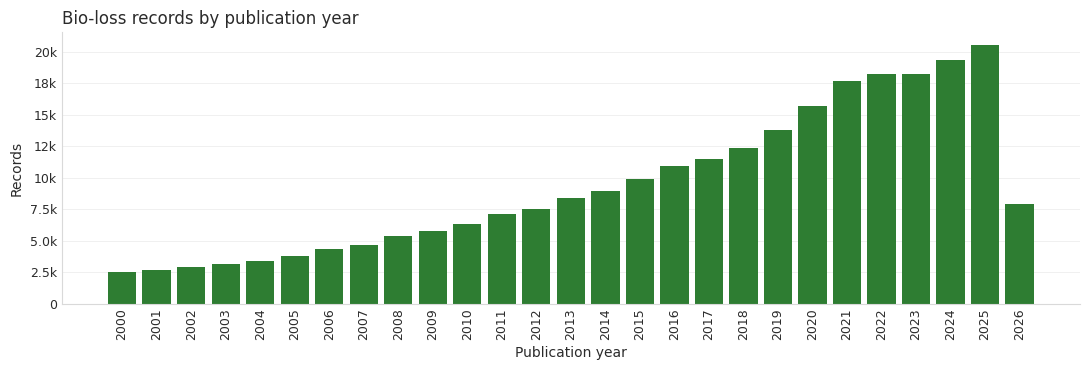

,publication_year,records
0,2000,2530
1,2001,2665
2,2002,2879
3,2003,3146
4,2004,3398
5,2005,3809
6,2006,4375
7,2007,4695
8,2008,5351
9,2009,5809


In [48]:
year_counts = plot_publication_year_counts(bio_loss_df, "Bio-loss records by publication year")
display(year_counts)


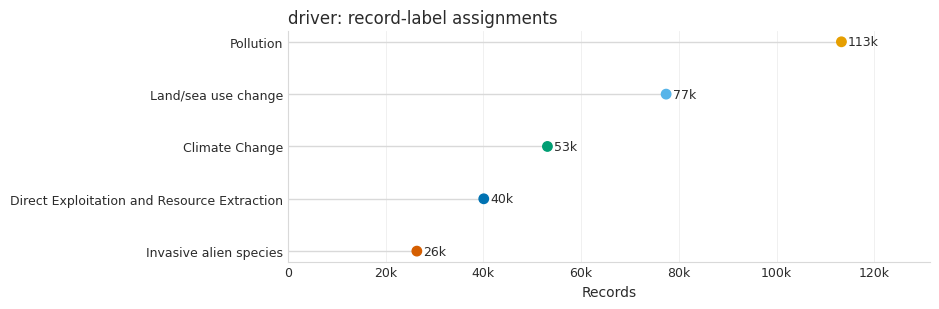

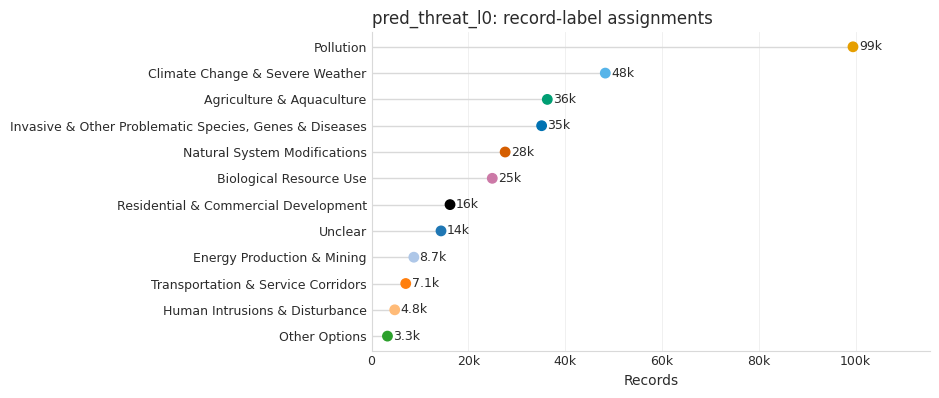

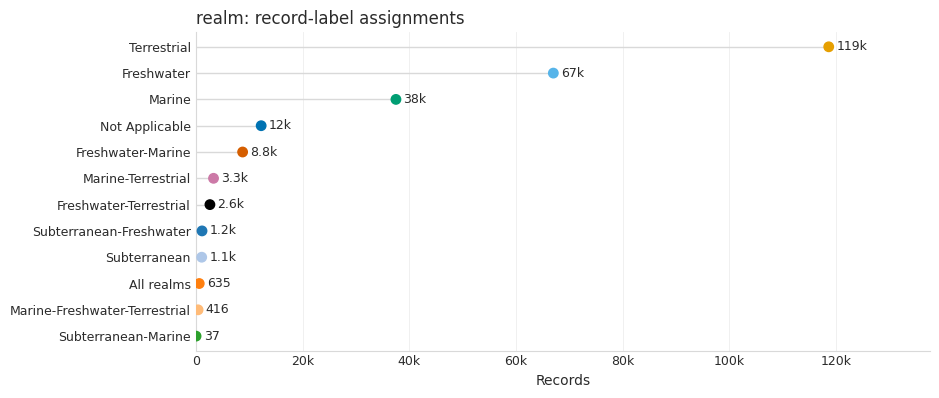

driver


,label,records,assignments
0,Pollution,113286,113286
1,Land/sea use change,77410,77410
2,Climate Change,53120,53120
3,Direct Exploitation and Resource Extraction,40091,40091
4,Invasive alien species,26397,26397


pred_threat_l0


,label,records,assignments
0,Pollution,99479,99479
1,Climate Change & Severe Weather,48292,48292
2,Agriculture & Aquaculture,36305,36305
3,"Invasive & Other Problematic Species, Genes & ...",35135,35135
4,Natural System Modifications,27596,27596
5,Biological Resource Use,24935,24935
6,Residential & Commercial Development,16205,16205
7,Unclear,14342,14342
8,Energy Production & Mining,8728,8728
9,Transportation & Service Corridors,7054,7054


realm


,label,records,assignments
0,Terrestrial,118622,118622
1,Freshwater,67003,67003
2,Marine,37503,37503
3,Not Applicable,12240,12240
4,Freshwater-Marine,8764,8764
5,Marine-Terrestrial,3311,3311
6,Freshwater-Terrestrial,2635,2635
7,Subterranean-Freshwater,1155,1155
8,Subterranean,1096,1096
9,All realms,635,635


In [49]:
label_cols = ["driver", "pred_threat_l0", "realm"]

overall_label_counts = {label_col: plot_label_distribution(bio_loss_df, label_col) for label_col in label_cols}

for label_col, counts in overall_label_counts.items():
    print(label_col)
    display(counts)


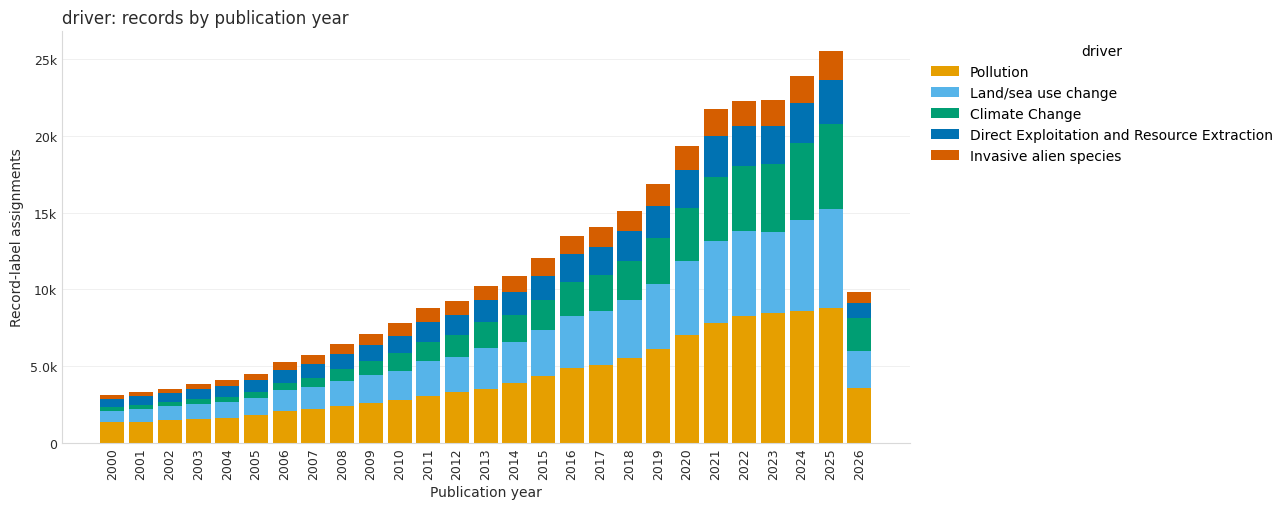

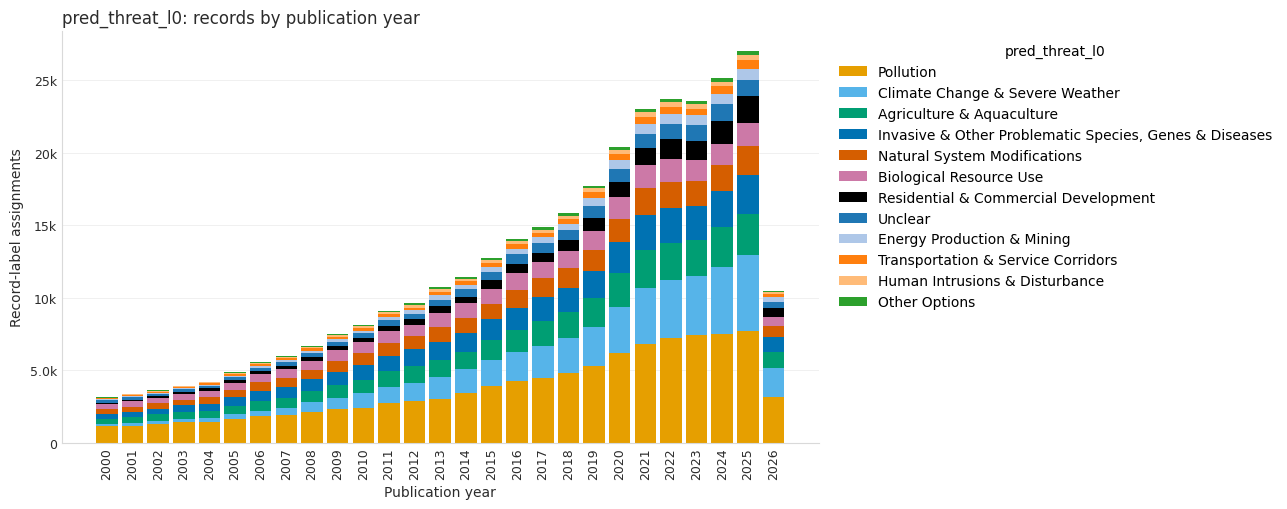

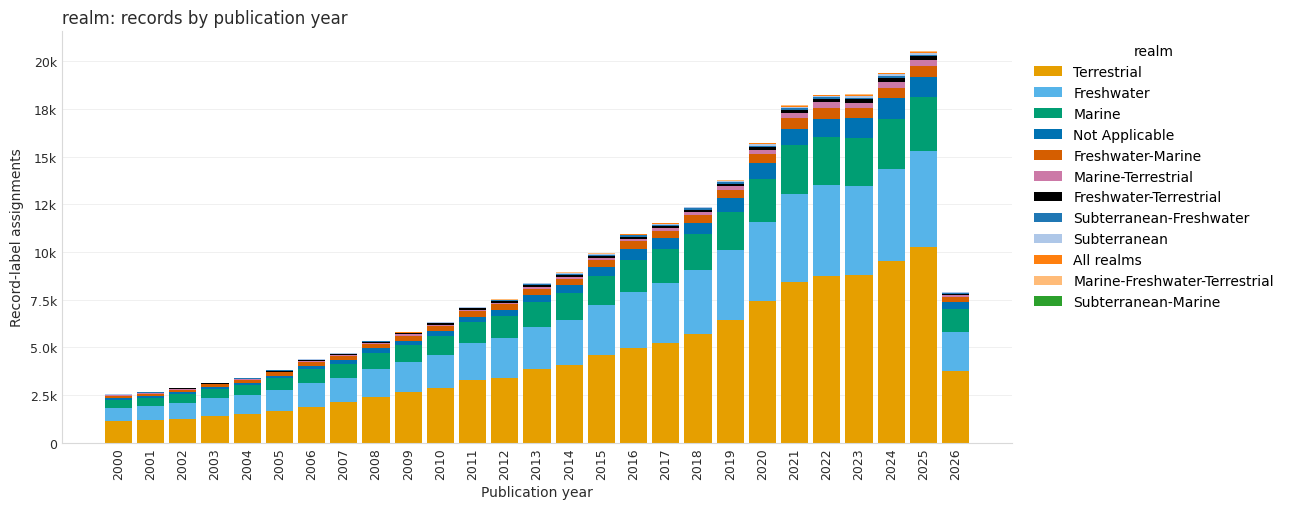

driver


,publication_year,label,records,assignments
0,2000,Pollution,1324,1324
1,2000,Land/sea use change,759,759
2,2000,Direct Exploitation and Resource Extraction,533,533
3,2000,Invasive alien species,251,251
4,2000,Climate Change,237,237
...,...,...,...,...
130,2026,Pollution,3581,3581
131,2026,Land/sea use change,2418,2418
132,2026,Climate Change,2117,2117
133,2026,Direct Exploitation and Resource Extraction,1018,1018


pred_threat_l0


,publication_year,label,records,assignments
0,2000,Pollution,1143,1143
1,2000,Biological Resource Use,359,359
2,2000,Agriculture & Aquaculture,355,355
3,2000,"Invasive & Other Problematic Species, Genes & ...",340,340
4,2000,Natural System Modifications,310,310
...,...,...,...,...
319,2026,Unclear,406,406
320,2026,Energy Production & Mining,322,322
321,2026,Transportation & Service Corridors,228,228
322,2026,Human Intrusions & Disturbance,142,142


realm


,publication_year,label,records,assignments
0,2000,Terrestrial,1118,1118
1,2000,Freshwater,725,725
2,2000,Marine,415,415
3,2000,Freshwater-Marine,118,118
4,2000,Not Applicable,92,92
...,...,...,...,...
309,2026,Subterranean,42,42
310,2026,Subterranean-Freshwater,33,33
311,2026,All realms,22,22
312,2026,Marine-Freshwater-Terrestrial,17,17


In [50]:
label_counts_by_year_tables = {
    label_col: plot_label_distribution_by_year(bio_loss_df, label_col)
    for label_col in label_cols
}

for label_col, counts in label_counts_by_year_tables.items():
    print(label_col)
    display(counts)


In [51]:
GROWTH_START_YEAR = 2000
GROWTH_END_YEAR = 2025
GROWTH_LABEL_COLS = ["driver", "pred_threat_l0"]


def growth_wide_counts(df: pd.DataFrame, label_col: str, start_year: int = GROWTH_START_YEAR, end_year: int = GROWTH_END_YEAR) -> pd.DataFrame:
    counts = label_counts_by_year(df, label_col)
    counts = counts.loc[counts["publication_year"].between(start_year, end_year)]

    years = list(range(start_year, end_year + 1))
    labels = label_counts(df, label_col)["label"].tolist()
    wide = (
        counts.pivot_table(index="label", columns="publication_year", values="records", fill_value=0, aggfunc="sum")
        .reindex(index=labels, columns=years, fill_value=0)
        .astype(int)
    )
    return wide


def growth_summary(df: pd.DataFrame, label_col: str, start_year: int = GROWTH_START_YEAR, end_year: int = GROWTH_END_YEAR) -> tuple[pd.DataFrame, pd.DataFrame]:
    wide = growth_wide_counts(df, label_col, start_year, end_year)
    periods = end_year - start_year
    yoy = wide.T.pct_change().T.replace([float("inf"), -float("inf")], pd.NA)

    summary = pd.DataFrame(index=wide.index)
    summary["records_2000"] = wide[start_year]
    summary["records_2025"] = wide[end_year]
    summary["absolute_change"] = summary["records_2025"] - summary["records_2000"]
    summary["pct_change_2000_2025"] = (summary["absolute_change"] / summary["records_2000"].where(summary["records_2000"].ne(0)))
    summary["cagr_2000_2025"] = (summary["records_2025"] / summary["records_2000"].where(summary["records_2000"].gt(0))) ** (1 / periods) - 1
    summary["mean_yoy_growth"] = yoy.mean(axis=1, skipna=True)
    summary["median_yoy_growth"] = yoy.median(axis=1, skipna=True)
    summary["years_with_records"] = wide.gt(0).sum(axis=1)
    summary["years_with_growth"] = wide.diff(axis=1).gt(0).sum(axis=1)
    summary["years_with_decline"] = wide.diff(axis=1).lt(0).sum(axis=1)

    first_nonzero_year = wide.gt(0).idxmax(axis=1)
    has_any_records = wide.gt(0).any(axis=1)
    summary["first_nonzero_year"] = first_nonzero_year.where(has_any_records, pd.NA)

    cagr_since_first = []
    for label, row in wide.iterrows():
        first_year = summary.loc[label, "first_nonzero_year"]
        end_value = row[end_year]
        if pd.isna(first_year) or first_year == end_year or row[first_year] <= 0 or end_value <= 0:
            cagr_since_first.append(pd.NA)
        else:
            cagr_since_first.append((end_value / row[first_year]) ** (1 / (end_year - first_year)) - 1)
    summary["cagr_since_first_nonzero"] = cagr_since_first

    summary = summary.reset_index().rename(columns={"label": label_col})
    summary = summary.sort_values(["cagr_2000_2025", "absolute_change"], ascending=[False, False], ignore_index=True)

    yoy_table = (
        yoy.reset_index()
        .melt(id_vars="label", var_name="publication_year", value_name="yoy_growth")
        .dropna(subset=["yoy_growth"])
        .rename(columns={"label": label_col})
        .sort_values(["publication_year", label_col], ignore_index=True)
    )
    return summary, yoy_table


def display_growth_summary(summary: pd.DataFrame, label_col: str, top_n: int | None = None) -> pd.DataFrame:
    display_cols = [
        label_col,
        "records_2000",
        "records_2025",
        "absolute_change",
        "pct_change_2000_2025",
        "cagr_2000_2025",
        "mean_yoy_growth",
        "median_yoy_growth",
        "years_with_growth",
        "years_with_decline",
        "first_nonzero_year",
        "cagr_since_first_nonzero",
    ]
    out = summary.loc[:, display_cols].copy()
    pct_cols = ["pct_change_2000_2025", "cagr_2000_2025", "mean_yoy_growth", "median_yoy_growth", "cagr_since_first_nonzero"]
    for col in pct_cols:
        out[col] = out[col].map(lambda value: pd.NA if pd.isna(value) else f"{value:.1%}")
    return out.head(top_n) if top_n else out


def plot_growth_summary(summary: pd.DataFrame, label_col: str, top_n: int | None = None):
    plot_df = summary.head(top_n).copy() if top_n else summary.copy()
    plot_df = plot_df.sort_values("cagr_2000_2025", ascending=True)
    colors = [BIODIVERSITY["primary"] if value >= 0 else BIODIVERSITY["ineligible"] for value in plot_df["cagr_2000_2025"].fillna(0)]

    fig, ax = plt.subplots(figsize=(9.5, max(3.2, 0.36 * len(plot_df))))
    ax.axvline(0, color=BIODIVERSITY["neutral"], linewidth=1)
    ax.scatter(plot_df["cagr_2000_2025"], plot_df[label_col], color=colors, s=48, zorder=3)
    for _, row in plot_df.iterrows():
        if pd.isna(row["cagr_2000_2025"]):
            continue
        offset = 0.003 if row["cagr_2000_2025"] >= 0 else -0.003
        ha = "left" if row["cagr_2000_2025"] >= 0 else "right"
        ax.text(row["cagr_2000_2025"] + offset, row[label_col], f"{row['cagr_2000_2025']:.1%}", va="center", ha=ha, fontsize=9)
    ax.set_title(f"{label_col}: CAGR, {GROWTH_START_YEAR}-{GROWTH_END_YEAR}", loc="left")
    ax.set_xlabel("Compound annual growth rate")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    style_axis(ax, "x")
    plt.tight_layout()
    plt.show()


def plot_yoy_growth_heatmap(yoy_table: pd.DataFrame, summary: pd.DataFrame, label_col: str, top_n: int | None = None):
    labels = summary.head(top_n)[label_col].tolist() if top_n else summary[label_col].tolist()
    heat = (
        yoy_table.loc[yoy_table[label_col].isin(labels)]
        .pivot_table(index=label_col, columns="publication_year", values="yoy_growth", aggfunc="mean")
        .reindex(index=labels)
    )

    fig, ax = plt.subplots(figsize=(12.5, max(3.4, 0.35 * len(heat))))
    im = ax.imshow(heat, aspect="auto", cmap="PuOr", vmin=-0.5, vmax=0.5)
    ax.set_title(f"{label_col}: year-over-year growth, {GROWTH_START_YEAR + 1}-{GROWTH_END_YEAR}", loc="left")
    ax.set_xlabel("Publication year")
    ax.set_ylabel("")
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels(heat.columns, rotation=90)
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    cbar.set_label("YoY growth")
    plt.tight_layout()
    plt.show()


driver: growth summary, 2000-2025


,driver,records_2000,records_2025,absolute_change,pct_change_2000_2025,cagr_2000_2025,mean_yoy_growth,median_yoy_growth,years_with_growth,years_with_decline,first_nonzero_year,cagr_since_first_nonzero
0,Climate Change,237,5571,5334,2250.6%,13.5%,13.7%,13.1%,25,0,2000,13.5%
1,Land/sea use change,759,6427,5668,746.8%,8.9%,9.1%,10.3%,23,2,2000,8.9%
2,Invasive alien species,251,1903,1652,658.2%,8.4%,8.7%,7.4%,21,3,2000,8.4%
3,Pollution,1324,8815,7491,565.8%,7.9%,8.0%,7.8%,25,0,2000,7.9%
4,Direct Exploitation and Resource Extraction,533,2831,2298,431.1%,6.9%,7.1%,8.1%,21,4,2000,6.9%


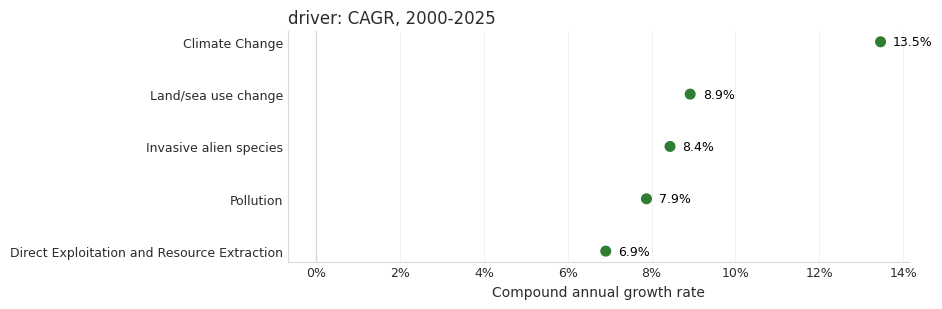

driver: year-over-year growth rates


,driver,publication_year,yoy_growth
0,Climate Change,2001,0.194093
1,Direct Exploitation and Resource Extraction,2001,0.061914
2,Invasive alien species,2001,0.147410
3,Land/sea use change,2001,0.105402
4,Pollution,2001,0.007553
...,...,...,...
120,Climate Change,2025,0.111532
121,Direct Exploitation and Resource Extraction,2025,0.085090
122,Invasive alien species,2025,0.071509
123,Land/sea use change,2025,0.083446


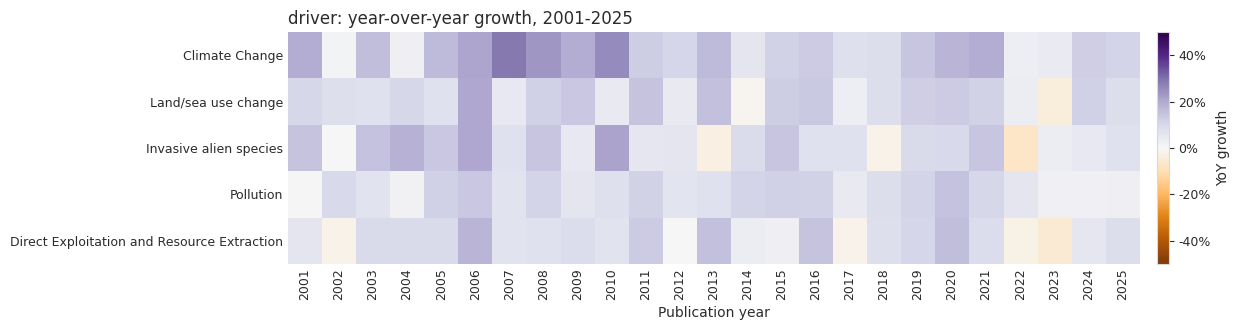

pred_threat_l0: growth summary, 2000-2025


,pred_threat_l0,records_2000,records_2025,absolute_change,pct_change_2000_2025,cagr_2000_2025,mean_yoy_growth,median_yoy_growth,years_with_growth,years_with_decline,first_nonzero_year,cagr_since_first_nonzero
0,Climate Change & Severe Weather,167,5208,5041,3018.6%,14.8%,15.1%,14.0%,24,1,2000,14.8%
1,Residential & Commercial Development,80,1833,1753,2191.2%,13.3%,13.8%,14.9%,23,2,2000,13.3%
2,Transportation & Service Corridors,56,610,554,989.3%,10.0%,10.9%,10.1%,20,5,2000,10.0%
3,Energy Production & Mining,75,758,683,910.7%,9.7%,10.2%,9.7%,21,4,2000,9.7%
4,Agriculture & Aquaculture,355,2862,2507,706.2%,8.7%,8.9%,9.7%,24,1,2000,8.7%
5,"Invasive & Other Problematic Species, Genes & ...",340,2697,2357,693.2%,8.6%,8.8%,7.0%,22,3,2000,8.6%
6,Other Options,37,257,220,594.6%,8.1%,8.9%,7.6%,19,6,2000,8.1%
7,Pollution,1143,7715,6572,575.0%,7.9%,8.0%,8.1%,25,0,2000,7.9%
8,Human Intrusions & Disturbance,52,350,298,573.1%,7.9%,8.6%,8.1%,17,7,2000,7.9%
9,Unclear,174,1137,963,553.4%,7.8%,8.2%,8.4%,20,5,2000,7.8%


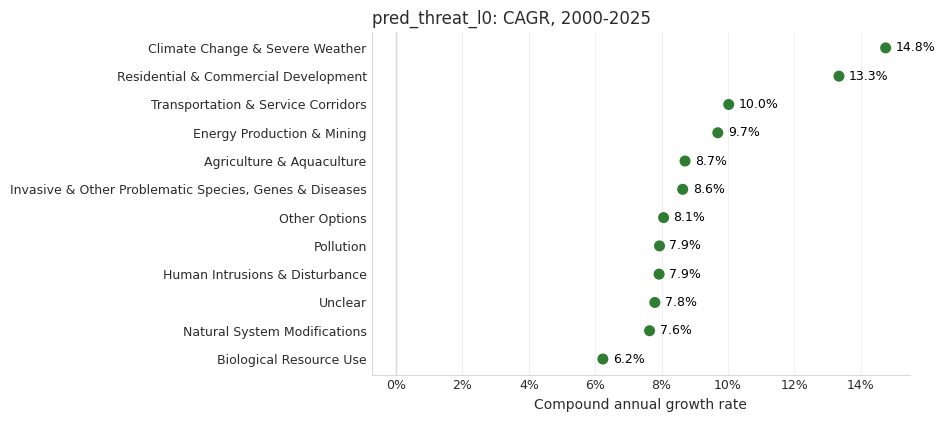

pred_threat_l0: year-over-year growth rates


,pred_threat_l0,publication_year,yoy_growth
0,Agriculture & Aquaculture,2001,0.104225
1,Biological Resource Use,2001,0.005571
2,Climate Change & Severe Weather,2001,0.317365
3,Energy Production & Mining,2001,-0.093333
4,Human Intrusions & Disturbance,2001,0.250000
...,...,...,...
295,Other Options,2025,0.070833
296,Pollution,2025,0.029765
297,Residential & Commercial Development,2025,0.149216
298,Transportation & Service Corridors,2025,0.210317


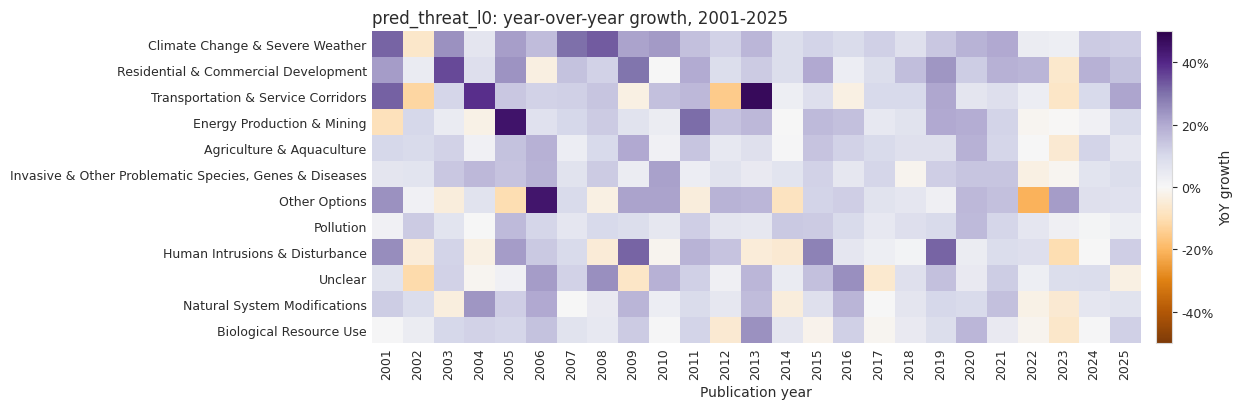

In [52]:
growth_summary_tables = {}
yoy_growth_tables = {}

for label_col in GROWTH_LABEL_COLS:
    summary, yoy = growth_summary(bio_loss_df, label_col)
    growth_summary_tables[label_col] = summary
    yoy_growth_tables[label_col] = yoy

    print(f"{label_col}: growth summary, {GROWTH_START_YEAR}-{GROWTH_END_YEAR}")
    display(display_growth_summary(summary, label_col))
    plot_growth_summary(summary, label_col)

    print(f"{label_col}: year-over-year growth rates")
    display(yoy)
    plot_yoy_growth_heatmap(yoy, summary, label_col)


In [53]:
bio_loss_df.head()

,UT,title,authors,abstract,source,publication_year,wos_categories,doi,eligibility,s1_r,...,pred_subregions,pred_countries,locales,locale_coordinates,realm,pred_study_design,pred_methods_data_collection,pred_methods_analysis,pred_has_comparison,pred_comparison_types
1,WOS:001498294300001,Size-dependent effects of oxo-degradable plast...,"[""Thanh, DK"", ""Brown, RW"", ""Graf, M"", ""Reay, M...",Agricultural plastic mulch film represents a s...,HIGHER EDUCATION PRESS,2026,"[""Agronomy""]",10.15302/J-FASE-2025623,ELIGIBLE,1,...,"[""North America""]","[""Not Applicable""]","[""Not Applicable""]",[],"[""Terrestrial""]",Experimental,"[""Mesocosm"", ""LabAssay""]","[""DiversityMetrics"", ""CommunityComposition_Mul...",True,"[""ControlImpact""]"
4,WOS:001509429700001,Effects of flooding on aquatic macroinvertebra...,"[""Wooden, PLS"", ""Kelso, WE"", ""Kaller, MD""]",The Atchafalaya River Basin is the largest con...,SPRINGER,2026,"[""Marine & Freshwater Biology""]",10.1007/s10750-025-05921-2,ELIGIBLE,1,...,"[""North America""]","[""USA""]","[""Atchafalaya River Basin (Louisiana)""]",[],"[""Freshwater""]",Observational,"[""FieldSurvey""]","[""DiversityMetrics"", ""CommunityComposition_Mul...",True,"[""SpatialGradient_NearFar_UpDownstream""]"
5,WOS:001510635100001,Minimizing Heavy Metal Contamination in Mining...,"[""Ganesh, CR"", ""Rao, KR"", ""Sumalatha, J"", ""Sre...",The foremost environmental challenge the world...,TAYLOR & FRANCIS INC,2026,"[""Environmental Sciences""]",10.1080/15320383.2025.2518147,ELIGIBLE,1,...,"[""North America""]","[""Not Applicable""]","[""Not Applicable""]",[],"[""Terrestrial""]",Experimental,"[""LabAssay""]","[""Other: ANOVA""]",True,"[""Other""]"
6,WOS:001512577600001,Physicochemical Characteristics and Potentiall...,"[""Kirana, KH"", ""Iman, MRR"", ""Shafaria, M"", ""Ag...",The midstream of the Citarum River is vital to...,TAYLOR & FRANCIS INC,2026,"[""Environmental Sciences""]",10.1080/15320383.2025.2519758,ELIGIBLE,1,...,"[""South-East Asia""]","[""IDN""]","[""Citarum River midstream"", ""Saguling Hydroele...",[],"[""Freshwater""]",Observational,[],"[""Other:StatisticalCorrelation""]",False,[]
12,WOS:001522363900001,Impacts of present heat waves in freshwater en...,"[""Riesco, MF"", ""Calvo-Rodríguez, L"", ""Esteban,...",Extreme temperature events are urgent concerns...,ELSEVIER,2026,"[""Fisheries"", ""Marine & Freshwater Biology""]",10.1016/j.aquaculture.2025.742879,ELIGIBLE,-1,...,"[""Central and Western Europe""]","[""ESP""]","[""Castilla y León""]",[],"[""Freshwater""]",Experimental,"[""FieldSurvey"", ""LabAssay""]","[""GLM_GLM_MixedEffects"", ""Other: Statistical c...",True,"[""TreatedUntreated""]"


In [54]:
bio_loss_df.pred_study_design.unique()

array(['Experimental', 'Observational', 'Modelling', 'Review', 'Unclear',
       nan], dtype=object)

In [55]:
STUDY_DESIGN_GROUPS = {
    "Experimental": "Experimental",
    "Observational": "Observational",
    "Modelling": "Modelling",
    "Review": "Other",
    "Unclear": "Other",
}
PRIMARY_EVIDENCE_STUDY_DESIGNS = {"Experimental", "Observational"}


def study_design_group(value) -> str:
    if pd.isna(value):
        return "Other"
    return STUDY_DESIGN_GROUPS.get(str(value).strip(), "Other")


def format_percent_columns(df: pd.DataFrame, pct_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in pct_cols:
        out[col] = out[col].map(lambda value: pd.NA if pd.isna(value) else f"{value:.1%}")
    return out


def single_category_year_counts(df: pd.DataFrame, category_col: str, start_year: int = GROWTH_START_YEAR, end_year: int = GROWTH_END_YEAR) -> pd.DataFrame:
    out = df[["UT", "publication_year", category_col]].copy()
    out["publication_year"] = pd.to_numeric(out["publication_year"], errors="coerce").astype("Int64")
    out = out.dropna(subset=["publication_year"])
    out = out.loc[out["publication_year"].between(start_year, end_year)]
    return (
        out.groupby(["publication_year", category_col], observed=True)["UT"]
        .nunique()
        .rename("records")
        .reset_index()
        .sort_values(["publication_year", category_col], ignore_index=True)
    )


def single_category_growth_summary(df: pd.DataFrame, category_col: str, start_year: int = GROWTH_START_YEAR, end_year: int = GROWTH_END_YEAR) -> tuple[pd.DataFrame, pd.DataFrame]:
    counts = single_category_year_counts(df, category_col, start_year, end_year)
    years = list(range(start_year, end_year + 1))
    categories = df[category_col].dropna().value_counts().index.tolist()
    wide = (
        counts.pivot_table(index=category_col, columns="publication_year", values="records", fill_value=0, aggfunc="sum")
        .reindex(index=categories, columns=years, fill_value=0)
        .astype(int)
    )
    yoy = wide.T.pct_change().T.replace([float("inf"), -float("inf")], pd.NA)
    periods = end_year - start_year

    summary = pd.DataFrame(index=wide.index)
    summary["records_2000"] = wide[start_year]
    summary["records_2025"] = wide[end_year]
    summary["absolute_change"] = summary["records_2025"] - summary["records_2000"]
    summary["pct_change_2000_2025"] = summary["absolute_change"] / summary["records_2000"].where(summary["records_2000"].ne(0))
    summary["cagr_2000_2025"] = (summary["records_2025"] / summary["records_2000"].where(summary["records_2000"].gt(0))) ** (1 / periods) - 1
    summary["mean_yoy_growth"] = yoy.mean(axis=1, skipna=True)
    summary["median_yoy_growth"] = yoy.median(axis=1, skipna=True)
    summary["years_with_growth"] = wide.diff(axis=1).gt(0).sum(axis=1)
    summary["years_with_decline"] = wide.diff(axis=1).lt(0).sum(axis=1)
    summary = summary.reset_index().sort_values(["cagr_2000_2025", "absolute_change"], ascending=[False, False], ignore_index=True)
    return summary, counts


def label_rankings_by_study_design(df: pd.DataFrame, label_col: str, group_col: str = "study_design_group") -> pd.DataFrame:
    exploded = exploded_labels(df, label_col)
    exploded = exploded.merge(df[["UT", group_col]], on="UT", how="left", validate="many_to_one")
    rankings = (
        exploded.groupby([group_col, "label"], observed=True)
        .agg(records=("UT", "nunique"))
        .reset_index()
    )
    group_totals = df.groupby(group_col, observed=True)["UT"].nunique().rename("group_records")
    rankings = rankings.merge(group_totals, on=group_col, how="left")
    rankings["share_within_group"] = rankings["records"] / rankings["group_records"]
    rankings["rank_within_group"] = rankings.groupby(group_col, observed=True)["records"].rank(method="dense", ascending=False).astype(int)
    return rankings.sort_values([group_col, "rank_within_group", "label"], ignore_index=True)


def label_growth_by_study_design(df: pd.DataFrame, label_col: str, group_col: str = "study_design_group", start_year: int = GROWTH_START_YEAR, end_year: int = GROWTH_END_YEAR) -> pd.DataFrame:
    exploded = exploded_labels(df, label_col)
    exploded = exploded.merge(df[["UT", group_col]], on="UT", how="left", validate="many_to_one")
    exploded = exploded.loc[exploded["publication_year"].between(start_year, end_year)]
    counts = (
        exploded.groupby([group_col, "label", "publication_year"], observed=True)["UT"]
        .nunique()
        .rename("records")
        .reset_index()
    )
    wide = counts.pivot_table(index=[group_col, "label"], columns="publication_year", values="records", fill_value=0, aggfunc="sum")
    wide = wide.reindex(columns=list(range(start_year, end_year + 1)), fill_value=0).astype(int)
    periods = end_year - start_year

    out = pd.DataFrame(index=wide.index)
    out["records_2000"] = wide[start_year]
    out["records_2025"] = wide[end_year]
    out["absolute_change"] = out["records_2025"] - out["records_2000"]
    out["pct_change_2000_2025"] = out["absolute_change"] / out["records_2000"].where(out["records_2000"].ne(0))
    out["cagr_2000_2025"] = (out["records_2025"] / out["records_2000"].where(out["records_2000"].gt(0))) ** (1 / periods) - 1
    out = out.reset_index()
    out["rank_2025_within_group"] = out.groupby(group_col, observed=True)["records_2025"].rank(method="dense", ascending=False).astype(int)
    return out.sort_values([group_col, "rank_2025_within_group", "label"], ignore_index=True)


bio_loss_df["study_design_group"] = bio_loss_df["pred_study_design"].map(study_design_group)
bio_loss_df["study_design_evidence_type"] = bio_loss_df["study_design_group"].map(
    lambda value: "Primary evidence" if value in PRIMARY_EVIDENCE_STUDY_DESIGNS else value
)

study_design_detail_counts = bio_loss_df["pred_study_design"].fillna("Missing").value_counts().rename_axis("pred_study_design").reset_index(name="records")
study_design_detail_counts["share"] = study_design_detail_counts["records"] / len(bio_loss_df)

study_design_group_counts = bio_loss_df["study_design_group"].value_counts().rename_axis("study_design_group").reset_index(name="records")
study_design_group_counts["share"] = study_design_group_counts["records"] / len(bio_loss_df)

study_design_evidence_type_counts = bio_loss_df["study_design_evidence_type"].value_counts().rename_axis("study_design_evidence_type").reset_index(name="records")
study_design_evidence_type_counts["share"] = study_design_evidence_type_counts["records"] / len(bio_loss_df)

study_design_group_growth, study_design_group_year_counts = single_category_growth_summary(bio_loss_df, "study_design_group")
study_design_group_year_pivot = study_design_group_year_counts.pivot_table(index="publication_year", columns="study_design_group", values="records", fill_value=0, aggfunc="sum")

study_design_driver_rankings = label_rankings_by_study_design(bio_loss_df, "driver")
study_design_threat_rankings = label_rankings_by_study_design(bio_loss_df, "pred_threat_l0")
study_design_driver_growth = label_growth_by_study_design(bio_loss_df, "driver")
study_design_threat_growth = label_growth_by_study_design(bio_loss_df, "pred_threat_l0")

print("Study design detail counts")
display(format_percent_columns(study_design_detail_counts, ["share"]))

print("Study design groups")
display(format_percent_columns(study_design_group_counts, ["share"]))

print("Primary evidence vs other study types")
display(format_percent_columns(study_design_evidence_type_counts, ["share"]))

print("Study design group growth, 2000-2025")
display(format_percent_columns(study_design_group_growth, ["pct_change_2000_2025", "cagr_2000_2025", "mean_yoy_growth", "median_yoy_growth"]))

print("Study design group records by year")
display(study_design_group_year_pivot)

print("Driver ranking by study design group")
display(format_percent_columns(study_design_driver_rankings, ["share_within_group"]))

print("Threat L0 ranking by study design group")
display(format_percent_columns(study_design_threat_rankings, ["share_within_group"]))

print("Driver growth by study design group, 2000-2025")
display(format_percent_columns(study_design_driver_growth, ["pct_change_2000_2025", "cagr_2000_2025"]))

print("Threat L0 growth by study design group, 2000-2025")
display(format_percent_columns(study_design_threat_growth, ["pct_change_2000_2025", "cagr_2000_2025"]))


Study design detail counts


,pred_study_design,records,share
0,Observational,116684,46.1%
1,Experimental,86536,34.2%
2,Modelling,33993,13.4%
3,Review,12705,5.0%
4,Unclear,3162,1.2%
5,Missing,1,0.0%


Study design groups


,study_design_group,records,share
0,Observational,116684,46.1%
1,Experimental,86536,34.2%
2,Modelling,33993,13.4%
3,Other,15868,6.3%


Primary evidence vs other study types


...

,study_design_group,label,records,group_records,share_within_group,rank_within_group
0,Experimental,Pollution,51959,86536,60.0%,1
1,Experimental,Climate Change & Severe Weather,9677,86536,11.2%,2
2,Experimental,Unclear,9611,86536,11.1%,3
3,Experimental,"Invasive & Other Problematic Species, Genes & ...",9547,86536,11.0%,4
4,Experimental,Agriculture & Aquaculture,5250,86536,6.1%,5
5,Experimental,Natural System Modifications,3219,86536,3.7%,6
6,Experimental,Biological Resource Use,2417,86536,2.8%,7
7,Experimental,Other Options,768,86536,0.9%,8
8,Experimental,Energy Production & Mining,625,86536,0.7%,9
9,Experimental,Human Intrusions & Disturbance,566,86536,0.7%,10


Driver growth by study design group, 2000-2025


,study_design_group,label,records_2000,records_2025,absolute_change,pct_change_2000_2025,cagr_2000_2025,rank_2025_within_group
0,Experimental,Pollution,704,4912,4208,597.7%,8.1%,1
1,Experimental,Climate Change,104,1214,1110,1067.3%,10.3%,2
2,Experimental,Land/sea use change,151,736,585,387.4%,6.5%,3
3,Experimental,Direct Exploitation and Resource Extraction,115,528,413,359.1%,6.3%,4
4,Experimental,Invasive alien species,88,525,437,496.6%,7.4%,5
5,Modelling,Climate Change,32,1584,1552,4850.0%,16.9%,1
6,Modelling,Land/sea use change,74,1477,1403,1895.9%,12.7%,2
7,Modelling,Pollution,52,584,532,1023.1%,10.2%,3
8,Modelling,Direct Exploitation and Resource Extraction,73,468,395,541.1%,7.7%,4
9,Modelling,Invasive alien species,14,218,204,1457.1%,11.6%,5


Threat L0 growth by study design group, 2000-2025


,study_design_group,label,records_2000,records_2025,absolute_change,pct_change_2000_2025,cagr_2000_2025,rank_2025_within_group
0,Experimental,Pollution,583,4094,3511,602.2%,8.1%,1
1,Experimental,Climate Change & Severe Weather,40,943,903,2257.5%,13.5%,2
2,Experimental,Unclear,115,760,645,560.9%,7.8%,3
3,Experimental,"Invasive & Other Problematic Species, Genes & ...",109,739,630,578.0%,8.0%,4
4,Experimental,Agriculture & Aquaculture,68,362,294,432.4%,6.9%,5
5,Experimental,Natural System Modifications,39,188,149,382.1%,6.5%,6
6,Experimental,Biological Resource Use,45,146,101,224.4%,4.8%,7
7,Experimental,Other Options,15,61,46,306.7%,5.8%,8
8,Experimental,Energy Production & Mining,6,51,45,750.0%,8.9%,9
9,Experimental,Residential & Commercial Development,2,25,23,1150.0%,10.6%,10


In [56]:
# Wider bio-loss literature analysis helpers.
ANALYSIS_START_YEAR = 2000
ANALYSIS_END_YEAR = 2025


def pct_table(df: pd.DataFrame, pct_cols: list[str]) -> pd.DataFrame:
    return format_percent_columns(df, pct_cols)


def display_top(df: pd.DataFrame, n: int = 30) -> pd.DataFrame:
    return df.head(n)


def year_totals(df: pd.DataFrame, start_year: int = ANALYSIS_START_YEAR, end_year: int = ANALYSIS_END_YEAR) -> pd.DataFrame:
    out = df[["UT", "publication_year"]].copy()
    out["publication_year"] = pd.to_numeric(out["publication_year"], errors="coerce").astype("Int64")
    out = out.dropna(subset=["publication_year"])
    out = out.loc[out["publication_year"].between(start_year, end_year)]
    return out.groupby("publication_year", observed=True)["UT"].nunique().rename("year_records").reset_index()


def exploded_label_with_cols(df: pd.DataFrame, label_col: str, extra_cols: list[str]) -> pd.DataFrame:
    out = exploded_labels(df, label_col)
    return out.merge(df[["UT", *extra_cols]], on="UT", how="left", validate="many_to_one")


def label_by_group_mix(df: pd.DataFrame, label_col: str, group_col: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    exploded = exploded_label_with_cols(df, label_col, [group_col])
    counts = (
        exploded.groupby(["label", group_col], observed=True)["UT"]
        .nunique()
        .rename("records")
        .reset_index()
    )
    label_totals = exploded.groupby("label", observed=True)["UT"].nunique().rename("label_records")
    counts = counts.merge(label_totals, on="label", how="left")
    counts["share_within_label"] = counts["records"] / counts["label_records"]
    counts = counts.sort_values(["label_records", "label", "records"], ascending=[False, True, False], ignore_index=True)

    count_wide = counts.pivot_table(index="label", columns=group_col, values="records", fill_value=0, aggfunc="sum")
    count_wide = count_wide.loc[label_totals.sort_values(ascending=False).index]
    share_wide = count_wide.div(count_wide.sum(axis=1), axis=0)
    return counts, count_wide, share_wide


def plot_stacked_share_table(share_wide: pd.DataFrame, title: str, top_n: int = 20):
    plot_df = share_wide.head(top_n)
    colors = color_map_for_labels(list(plot_df.columns))
    fig, ax = plt.subplots(figsize=(10.5, max(3.5, 0.35 * len(plot_df))))
    left = pd.Series(0.0, index=plot_df.index)
    for col in plot_df.columns:
        ax.barh(plot_df.index, plot_df[col], left=left, label=col, color=colors[col])
        left = left + plot_df[col]
    ax.set_title(title, loc="left")
    ax.set_xlabel("Share within label")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.legend(title="Group", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
    style_axis(ax, "x")
    plt.tight_layout()
    plt.show()


def multilabel_cross_counts(df: pd.DataFrame, row_col: str, col_col: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rows = exploded_labels(df, row_col)[["UT", "label"]].rename(columns={"label": row_col})
    cols = exploded_labels(df, col_col)[["UT", "label"]].rename(columns={"label": col_col})
    joined = rows.merge(cols, on="UT", how="inner")
    counts = joined.groupby([row_col, col_col], observed=True)["UT"].nunique().rename("records").reset_index()
    count_wide = counts.pivot_table(index=row_col, columns=col_col, values="records", fill_value=0, aggfunc="sum")
    row_totals = count_wide.sum(axis=1).sort_values(ascending=False)
    col_totals = count_wide.sum(axis=0).sort_values(ascending=False)
    count_wide = count_wide.loc[row_totals.index, col_totals.index]
    row_share = count_wide.div(count_wide.sum(axis=1), axis=0)
    return counts, count_wide, row_share


def single_vs_multilabel_counts(df: pd.DataFrame, row_col: str, label_col: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    labels = exploded_label_with_cols(df, label_col, [row_col])
    counts = labels.groupby([row_col, "label"], observed=True)["UT"].nunique().rename("records").reset_index()
    count_wide = counts.pivot_table(index=row_col, columns="label", values="records", fill_value=0, aggfunc="sum")
    count_wide = count_wide.loc[count_wide.sum(axis=1).sort_values(ascending=False).index, count_wide.sum(axis=0).sort_values(ascending=False).index]
    row_share = count_wide.div(count_wide.sum(axis=1), axis=0)
    return counts, count_wide, row_share


def plot_heatmap(table: pd.DataFrame, title: str, top_rows: int = 20, top_cols: int = 15, fmt: str = "percent"):
    plot_df = table.iloc[:top_rows, :top_cols]
    fig, ax = plt.subplots(figsize=(max(8, 0.55 * len(plot_df.columns)), max(4, 0.35 * len(plot_df))))
    im = ax.imshow(plot_df, aspect="auto", cmap="cividis")
    ax.set_title(title, loc="left")
    ax.set_xticks(range(len(plot_df.columns)))
    ax.set_xticklabels(plot_df.columns, rotation=90)
    ax.set_yticks(range(len(plot_df.index)))
    ax.set_yticklabels(plot_df.index)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    if fmt == "percent":
        cbar.ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    else:
        cbar.ax.yaxis.set_major_formatter(lambda x, _: format_count(x))
    plt.tight_layout()
    plt.show()


def top_category_values(df: pd.DataFrame, label_col: str, n: int) -> list[str]:
    return label_counts(df, label_col).head(n)["label"].tolist()


driver: study-design mix by label


,label,study_design_group,records,label_records,share_within_label
0,Pollution,Experimental,62559,113286,55.2%
1,Pollution,Observational,37899,113286,33.5%
2,Pollution,Modelling,7015,113286,6.2%
3,Pollution,Other,5813,113286,5.1%
4,Land/sea use change,Observational,47779,77410,61.7%
5,Land/sea use change,Modelling,13460,77410,17.4%
6,Land/sea use change,Experimental,10155,77410,13.1%
7,Land/sea use change,Other,6016,77410,7.8%
8,Climate Change,Observational,22290,53120,42.0%
9,Climate Change,Experimental,13273,53120,25.0%


driver: count table by study-design group


study_design_group,Experimental,Modelling,Observational,Other
label,,,,
Pollution,62559,7015,37899,5813
Land/sea use change,10155,13460,47779,6016
Climate Change,13273,13028,22290,4529
Direct Exploitation and Resource Extraction,7278,6036,22998,3779
Invasive alien species,7531,2469,14059,2338


driver: share table by study-design group


study_design_group,label,Experimental,Modelling,Observational,Other
0,Pollution,55.2%,6.2%,33.5%,5.1%
1,Land/sea use change,13.1%,17.4%,61.7%,7.8%
2,Climate Change,25.0%,24.5%,42.0%,8.5%
3,Direct Exploitation and Resource Extraction,18.2%,15.1%,57.4%,9.4%
4,Invasive alien species,28.5%,9.4%,53.3%,8.9%


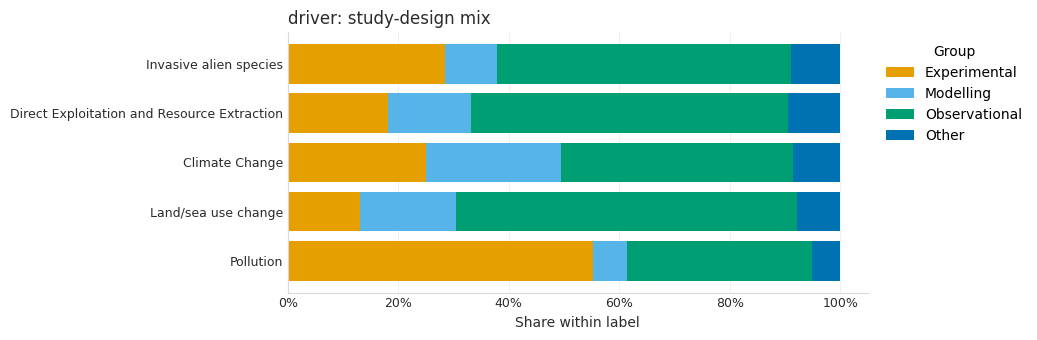

pred_threat_l0: study-design mix by label


,label,study_design_group,records,label_records,share_within_label
0,Pollution,Experimental,51959,99479,52.2%
1,Pollution,Observational,35177,99479,35.4%
2,Pollution,Modelling,6901,99479,6.9%
3,Pollution,Other,5442,99479,5.5%
4,Climate Change & Severe Weather,Observational,21634,48292,44.8%
5,Climate Change & Severe Weather,Modelling,12684,48292,26.3%
6,Climate Change & Severe Weather,Experimental,9677,48292,20.0%
7,Climate Change & Severe Weather,Other,4297,48292,8.9%
8,Agriculture & Aquaculture,Observational,22006,36305,60.6%
9,Agriculture & Aquaculture,Modelling,6188,36305,17.0%


pred_threat_l0: count table by study-design group


study_design_group,Experimental,Modelling,Observational,Other
label,,,,
Pollution,51959,6901,35177,5442
Climate Change & Severe Weather,9677,12684,21634,4297
Agriculture & Aquaculture,5250,6188,22006,2861
"Invasive & Other Problematic Species, Genes & Diseases",9547,3159,19494,2935
Natural System Modifications,3219,4922,17124,2331
Biological Resource Use,2417,4014,15874,2630
Residential & Commercial Development,211,4014,10845,1135
Unclear,9611,759,3363,609
Energy Production & Mining,625,1604,5436,1063


pred_threat_l0: share table by study-design group


study_design_group,label,Experimental,Modelling,Observational,Other
0,Pollution,52.2%,6.9%,35.4%,5.5%
1,Climate Change & Severe Weather,20.0%,26.3%,44.8%,8.9%
2,Agriculture & Aquaculture,14.5%,17.0%,60.6%,7.9%
3,"Invasive & Other Problematic Species, Genes & ...",27.2%,9.0%,55.5%,8.4%
4,Natural System Modifications,11.7%,17.8%,62.1%,8.4%
5,Biological Resource Use,9.7%,16.1%,63.7%,10.5%
6,Residential & Commercial Development,1.3%,24.8%,66.9%,7.0%
7,Unclear,67.0%,5.3%,23.4%,4.2%
8,Energy Production & Mining,7.2%,18.4%,62.3%,12.2%
9,Transportation & Service Corridors,4.2%,19.4%,68.1%,8.3%


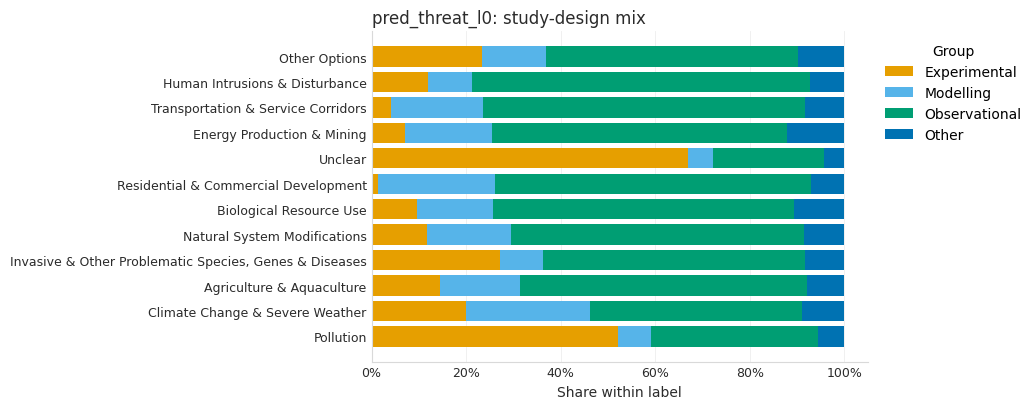

In [57]:
# 1. Evidence mix by driver and threat.
evidence_mix_tables = {}
for label_col in ["driver", "pred_threat_l0"]:
    long_counts, count_wide, share_wide = label_by_group_mix(bio_loss_df, label_col, "study_design_group")
    evidence_mix_tables[label_col] = {"long": long_counts, "counts": count_wide, "shares": share_wide}

    print(f"{label_col}: study-design mix by label")
    display(pct_table(display_top(long_counts, 60), ["share_within_label"]))

    print(f"{label_col}: count table by study-design group")
    display(count_wide)

    print(f"{label_col}: share table by study-design group")
    display(pct_table(share_wide.reset_index(), list(share_wide.columns)))
    plot_stacked_share_table(share_wide, f"{label_col}: study-design mix", top_n=20)


driver: growth adjusted for total bio-loss literature growth


,driver,records_2000,records_2025,share_2000,share_2025,share_pp_change,share_relative_change,share_cagr,topic_position
0,Climate Change,237,5571,9.4%,27.1%,17.8%,189.8%,4.3%,Dominant expanding
1,Land/sea use change,759,6427,30.0%,31.3%,1.3%,4.4%,0.2%,Dominant expanding
2,Invasive alien species,251,1903,9.9%,9.3%,-0.6%,-6.5%,-0.3%,Emerging
3,Direct Exploitation and Resource Extraction,533,2831,21.1%,13.8%,-7.3%,-34.5%,-1.7%,Niche or declining
4,Pollution,1324,8815,52.3%,43.0%,-9.4%,-17.9%,-0.8%,Mature or saturated


driver: yearly share table


,publication_year,label,records,assignments,year_records,share_of_year_records
0,2000,Pollution,1324,1324,2530,52.3%
1,2000,Land/sea use change,759,759,2530,30.0%
2,2000,Direct Exploitation and Resource Extraction,533,533,2530,21.1%
3,2000,Invasive alien species,251,251,2530,9.9%
4,2000,Climate Change,237,237,2530,9.4%
...,...,...,...,...,...,...
75,2015,Pollution,4367,4367,9917,44.0%
76,2015,Land/sea use change,2975,2975,9917,30.0%
77,2015,Climate Change,1960,1960,9917,19.8%
78,2015,Direct Exploitation and Resource Extraction,1578,1578,9917,15.9%


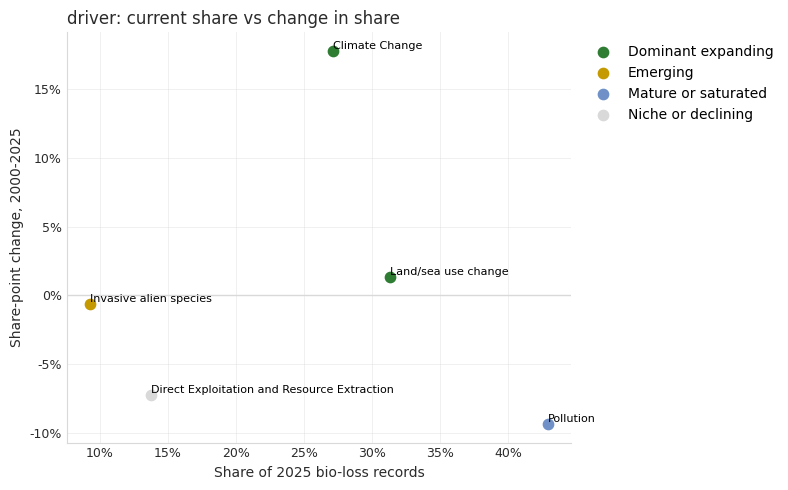

pred_threat_l0: growth adjusted for total bio-loss literature growth


,pred_threat_l0,records_2000,records_2025,share_2000,share_2025,share_pp_change,share_relative_change,share_cagr,topic_position
0,Climate Change & Severe Weather,167,5208,6.6%,25.4%,18.8%,284.5%,5.5%,Dominant expanding
1,Residential & Commercial Development,80,1833,3.2%,8.9%,5.8%,182.5%,4.2%,Dominant expanding
2,Transportation & Service Corridors,56,610,2.2%,3.0%,0.8%,34.3%,1.2%,Emerging
3,Energy Production & Mining,75,758,3.0%,3.7%,0.7%,24.6%,0.9%,Emerging
4,Agriculture & Aquaculture,355,2862,14.0%,13.9%,-0.1%,-0.6%,-0.0%,Dominant expanding
5,Other Options,37,257,1.5%,1.3%,-0.2%,-14.4%,-0.6%,Emerging
6,"Invasive & Other Problematic Species, Genes & ...",340,2697,13.4%,13.1%,-0.3%,-2.2%,-0.1%,Mature or saturated
7,Human Intrusions & Disturbance,52,350,2.1%,1.7%,-0.3%,-17.0%,-0.7%,Niche or declining
8,Unclear,174,1137,6.9%,5.5%,-1.3%,-19.4%,-0.9%,Niche or declining
9,Natural System Modifications,310,1952,12.3%,9.5%,-2.7%,-22.4%,-1.0%,Mature or saturated


pred_threat_l0: yearly share table


,publication_year,label,records,assignments,year_records,share_of_year_records
0,2000,Pollution,1143,1143,2530,45.2%
1,2000,Biological Resource Use,359,359,2530,14.2%
2,2000,Agriculture & Aquaculture,355,355,2530,14.0%
3,2000,"Invasive & Other Problematic Species, Genes & ...",340,340,2530,13.4%
4,2000,Natural System Modifications,310,310,2530,12.3%
...,...,...,...,...,...,...
75,2006,Natural System Modifications,611,611,4375,14.0%
76,2006,Biological Resource Use,585,585,4375,13.4%
77,2006,Climate Change & Severe Weather,383,383,4375,8.8%
78,2006,Unclear,228,228,4375,5.2%


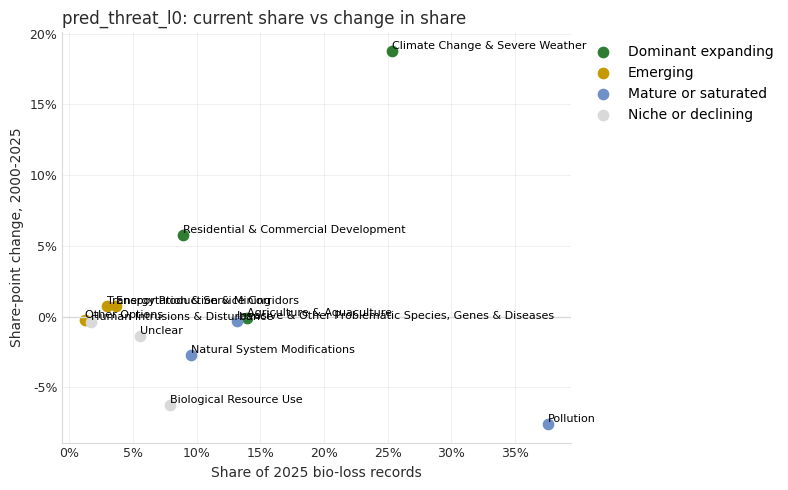

In [58]:
# 2-3. Growth adjusted for total literature growth, plus emerging vs mature classes.
def label_share_growth(df: pd.DataFrame, label_col: str, start_year: int = ANALYSIS_START_YEAR, end_year: int = ANALYSIS_END_YEAR) -> tuple[pd.DataFrame, pd.DataFrame]:
    counts = label_counts_by_year(df, label_col)
    counts = counts.loc[counts["publication_year"].between(start_year, end_year)].copy()
    totals = year_totals(df, start_year, end_year)
    counts = counts.merge(totals, on="publication_year", how="left")
    counts["share_of_year_records"] = counts["records"] / counts["year_records"]

    years = list(range(start_year, end_year + 1))
    labels = label_counts(df, label_col)["label"].tolist()
    count_wide = counts.pivot_table(index="label", columns="publication_year", values="records", fill_value=0, aggfunc="sum").reindex(index=labels, columns=years, fill_value=0)
    share_wide = counts.pivot_table(index="label", columns="publication_year", values="share_of_year_records", fill_value=0, aggfunc="sum").reindex(index=labels, columns=years, fill_value=0)
    periods = end_year - start_year

    summary = pd.DataFrame(index=labels)
    summary["records_2000"] = count_wide[start_year]
    summary["records_2025"] = count_wide[end_year]
    summary["share_2000"] = share_wide[start_year]
    summary["share_2025"] = share_wide[end_year]
    summary["share_pp_change"] = summary["share_2025"] - summary["share_2000"]
    summary["share_relative_change"] = summary["share_pp_change"] / summary["share_2000"].where(summary["share_2000"].ne(0))
    summary["share_cagr"] = (summary["share_2025"] / summary["share_2000"].where(summary["share_2000"].gt(0))) ** (1 / periods) - 1

    volume_cut = summary["share_2025"].median()
    growth_cut = summary["share_pp_change"].median()
    summary["topic_position"] = [
        "Dominant expanding" if row.share_2025 >= volume_cut and row.share_pp_change >= growth_cut else
        "Mature or saturated" if row.share_2025 >= volume_cut and row.share_pp_change < growth_cut else
        "Emerging" if row.share_2025 < volume_cut and row.share_pp_change >= growth_cut else
        "Niche or declining"
        for row in summary.itertuples()
    ]
    summary = summary.reset_index().rename(columns={"index": label_col}).sort_values(["share_pp_change", "records_2025"], ascending=[False, False], ignore_index=True)
    yearly = counts.sort_values(["publication_year", "records"], ascending=[True, False], ignore_index=True)
    return summary, yearly


def plot_share_growth(summary: pd.DataFrame, label_col: str):
    colors = {
        "Dominant expanding": BIODIVERSITY["primary"],
        "Mature or saturated": BIODIVERSITY["screening"],
        "Emerging": BIODIVERSITY["unclear"],
        "Niche or declining": BIODIVERSITY["neutral"],
    }
    fig, ax = plt.subplots(figsize=(8, 5))
    for topic_position, group in summary.groupby("topic_position", observed=True):
        ax.scatter(group["share_2025"], group["share_pp_change"], label=topic_position, color=colors[topic_position], s=55)
        for _, row in group.iterrows():
            ax.text(row["share_2025"], row["share_pp_change"], str(row[label_col]), fontsize=8, ha="left", va="bottom")
    ax.axhline(0, color=BIODIVERSITY["neutral"], linewidth=1)
    ax.set_title(f"{label_col}: current share vs change in share", loc="left")
    ax.set_xlabel("Share of 2025 bio-loss records")
    ax.set_ylabel("Share-point change, 2000-2025")
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
    style_axis(ax, "both")
    plt.tight_layout()
    plt.show()


share_growth_tables = {}
for label_col in ["driver", "pred_threat_l0"]:
    summary, yearly = label_share_growth(bio_loss_df, label_col)
    share_growth_tables[label_col] = {"summary": summary, "yearly": yearly}

    print(f"{label_col}: growth adjusted for total bio-loss literature growth")
    display(pct_table(summary, ["share_2000", "share_2025", "share_pp_change", "share_relative_change", "share_cagr"]))

    print(f"{label_col}: yearly share table")
    display(pct_table(display_top(yearly, 80), ["share_of_year_records"]))
    plot_share_growth(summary, label_col)


Driver x threat L0 counts


pred_threat_l0,Pollution,Climate Change & Severe Weather,Agriculture & Aquaculture,"Invasive & Other Problematic Species, Genes & Diseases",Natural System Modifications,Biological Resource Use,Unclear,Residential & Commercial Development,Energy Production & Mining,Transportation & Service Corridors,Human Intrusions & Disturbance,Other Options
driver,,,,,,,,,,,,
Pollution,94261,5608,7337,9705,5044,2406,8143,2345,2543,1001,1189,789
Land/sea use change,10167,9558,29424,6806,19516,7665,6484,15509,5705,5678,3023,2376
Climate Change,5983,43781,4733,5292,5976,2770,3299,1891,880,559,685,461
Direct Exploitation and Resource Extraction,4972,4400,7039,3688,6655,22217,3546,1672,3903,1479,1249,603
Invasive alien species,1849,2154,1748,21103,2032,1256,2832,697,302,736,435,383


Driver x threat L0 row shares


pred_threat_l0,driver,Pollution,Climate Change & Severe Weather,Agriculture & Aquaculture,"Invasive & Other Problematic Species, Genes & Diseases",Natural System Modifications,Biological Resource Use,Unclear,Residential & Commercial Development,Energy Production & Mining,Transportation & Service Corridors,Human Intrusions & Disturbance,Other Options
0,Pollution,67.2%,4.0%,5.2%,6.9%,3.6%,1.7%,5.8%,1.7%,1.8%,0.7%,0.8%,0.6%
1,Land/sea use change,8.3%,7.8%,24.1%,5.6%,16.0%,6.3%,5.3%,12.7%,4.7%,4.7%,2.5%,1.9%
2,Climate Change,7.8%,57.4%,6.2%,6.9%,7.8%,3.6%,4.3%,2.5%,1.2%,0.7%,0.9%,0.6%
3,Direct Exploitation and Resource Extraction,8.1%,7.2%,11.5%,6.0%,10.8%,36.2%,5.8%,2.7%,6.4%,2.4%,2.0%,1.0%
4,Invasive alien species,5.2%,6.1%,4.9%,59.4%,5.7%,3.5%,8.0%,2.0%,0.9%,2.1%,1.2%,1.1%


/var/folders/sf/ksfgwr354pl2gjdb_f0yn3vr0000gn/T/ipykernel_47587/1391281643.py:103: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


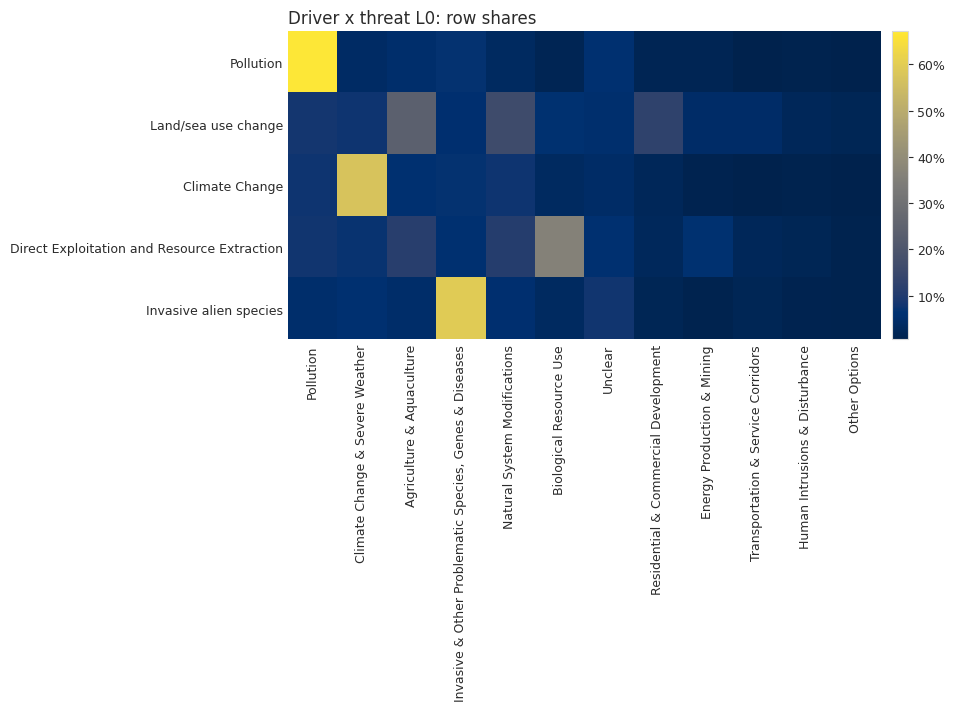

In [59]:
# 4. Driver-threat crosswalk.
driver_threat_long, driver_threat_counts, driver_threat_row_shares = multilabel_cross_counts(bio_loss_df, "driver", "pred_threat_l0")

print("Driver x threat L0 counts")
display(driver_threat_counts)

print("Driver x threat L0 row shares")
display(pct_table(driver_threat_row_shares.reset_index(), list(driver_threat_row_shares.columns)))
plot_heatmap(driver_threat_row_shares, "Driver x threat L0: row shares", top_rows=20, top_cols=20)


Realm x driver counts


driver,Pollution,Land/sea use change,Climate Change,Direct Exploitation and Resource Extraction,Invasive alien species
realm,,,,,
Terrestrial,38102,47135,28508,18465,14294
Freshwater,41964,17158,8391,6735,6846
Marine,16329,4819,10286,10643,2517
Not Applicable,9009,2118,1885,1665,1114
Freshwater-Marine,4866,2444,1617,1175,719
Marine-Terrestrial,801,1548,1174,468,262
Freshwater-Terrestrial,704,1352,572,304,356
Subterranean-Freshwater,804,182,138,278,17
Subterranean,564,276,183,205,116


Realm x driver shares


driver,realm,Pollution,Land/sea use change,Climate Change,Direct Exploitation and Resource Extraction,Invasive alien species
0,Terrestrial,26.0%,32.2%,19.5%,12.6%,9.8%
1,Freshwater,51.7%,21.2%,10.3%,8.3%,8.4%
2,Marine,36.6%,10.8%,23.1%,23.9%,5.6%
3,Not Applicable,57.1%,13.4%,11.9%,10.5%,7.1%
4,Freshwater-Marine,45.0%,22.6%,14.9%,10.9%,6.6%
5,Marine-Terrestrial,18.8%,36.4%,27.6%,11.0%,6.2%
6,Freshwater-Terrestrial,21.4%,41.1%,17.4%,9.2%,10.8%
7,Subterranean-Freshwater,56.7%,12.8%,9.7%,19.6%,1.2%
8,Subterranean,42.0%,20.5%,13.6%,15.3%,8.6%
9,All realms,23.2%,22.4%,28.9%,11.8%,13.7%


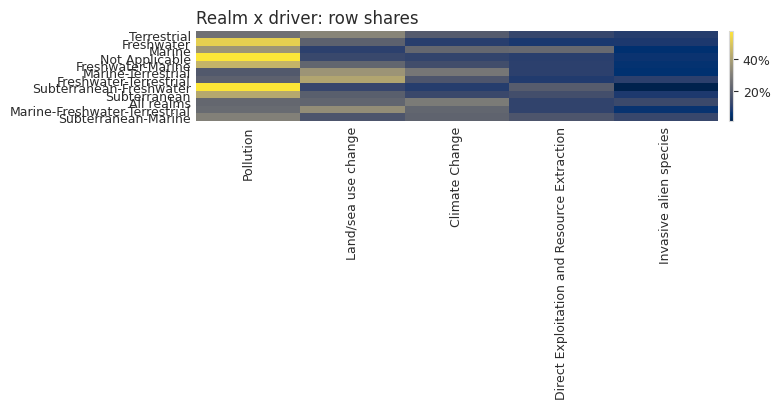

Realm x threat L0 counts


pred_threat_l0,Pollution,Climate Change & Severe Weather,Agriculture & Aquaculture,"Invasive & Other Problematic Species, Genes & Diseases",Natural System Modifications,Biological Resource Use,Residential & Commercial Development,Unclear,Energy Production & Mining,Transportation & Service Corridors,Human Intrusions & Disturbance,Other Options
realm,,,,,,,,,,,,
Terrestrial,30804,25437,25756,18448,9646,10740,10153,6941,3060,4651,2674,1999
Freshwater,39458,7730,6557,9502,11962,2848,3235,2793,3821,1073,640,473
Marine,15376,9886,1263,3920,1671,9248,953,1209,803,794,963,321
Not Applicable,6178,1106,467,1068,155,685,181,2983,299,73,52,290
Freshwater-Marine,4879,1669,747,961,1891,805,626,151,268,207,111,60
Marine-Terrestrial,788,1259,495,290,578,334,668,82,104,129,177,68
Freshwater-Terrestrial,693,554,594,397,1039,112,196,54,157,68,64,19
Subterranean-Freshwater,709,140,122,200,339,9,60,23,65,6,9,2
Subterranean,446,153,110,192,150,68,47,81,90,21,70,17


Realm x threat L0 shares


pred_threat_l0,realm,Pollution,Climate Change & Severe Weather,Agriculture & Aquaculture,"Invasive & Other Problematic Species, Genes & Diseases",Natural System Modifications,Biological Resource Use,Residential & Commercial Development,Unclear,Energy Production & Mining,Transportation & Service Corridors,Human Intrusions & Disturbance,Other Options
0,Terrestrial,20.5%,16.9%,17.1%,12.3%,6.4%,7.1%,6.8%,4.6%,2.0%,3.1%,1.8%,1.3%
1,Freshwater,43.8%,8.6%,7.3%,10.5%,13.3%,3.2%,3.6%,3.1%,4.2%,1.2%,0.7%,0.5%
2,Marine,33.1%,21.3%,2.7%,8.4%,3.6%,19.9%,2.1%,2.6%,1.7%,1.7%,2.1%,0.7%
3,Not Applicable,45.6%,8.2%,3.4%,7.9%,1.1%,5.1%,1.3%,22.0%,2.2%,0.5%,0.4%,2.1%
4,Freshwater-Marine,39.4%,13.5%,6.0%,7.8%,15.3%,6.5%,5.1%,1.2%,2.2%,1.7%,0.9%,0.5%
5,Marine-Terrestrial,15.8%,25.3%,10.0%,5.8%,11.6%,6.7%,13.4%,1.6%,2.1%,2.6%,3.6%,1.4%
6,Freshwater-Terrestrial,17.6%,14.0%,15.0%,10.1%,26.3%,2.8%,5.0%,1.4%,4.0%,1.7%,1.6%,0.5%
7,Subterranean-Freshwater,42.1%,8.3%,7.2%,11.9%,20.1%,0.5%,3.6%,1.4%,3.9%,0.4%,0.5%,0.1%
8,Subterranean,30.9%,10.6%,7.6%,13.3%,10.4%,4.7%,3.3%,5.6%,6.2%,1.5%,4.8%,1.2%
9,All realms,21.7%,25.8%,12.8%,15.1%,2.4%,7.9%,3.4%,2.4%,2.6%,1.7%,1.2%,3.0%


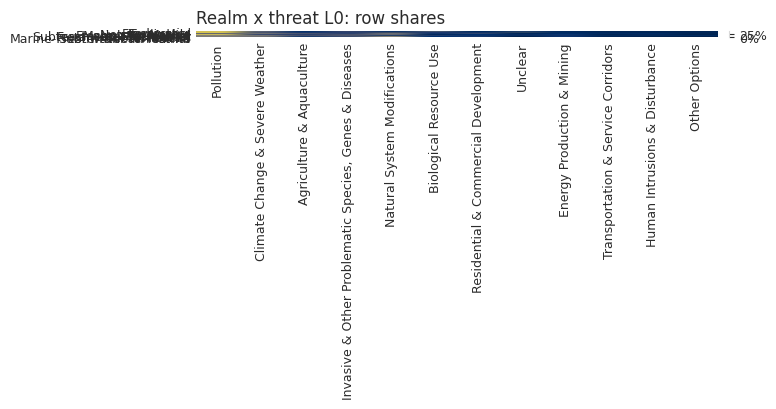

Realm x study design counts


study_design_group,Observational,Experimental,Modelling,Other
label,,,,
Terrestrial,56947,37368,17583,6724
Freshwater,29776,26903,7329,2995
Marine,17664,11698,5350,2791
Not Applicable,1807,7371,1132,1930
Freshwater-Marine,5357,1715,1174,518
Marine-Terrestrial,2019,376,592,324
Freshwater-Terrestrial,1590,610,315,120
Subterranean-Freshwater,669,218,204,64
Subterranean,559,370,112,55


Realm x study design shares


study_design_group,label,Observational,Experimental,Modelling,Other
0,Terrestrial,48.0%,31.5%,14.8%,5.7%
1,Freshwater,44.4%,40.2%,10.9%,4.5%
2,Marine,47.1%,31.2%,14.3%,7.4%
3,Not Applicable,14.8%,60.2%,9.2%,15.8%
4,Freshwater-Marine,61.1%,19.6%,13.4%,5.9%
5,Marine-Terrestrial,61.0%,11.4%,17.9%,9.8%
6,Freshwater-Terrestrial,60.3%,23.1%,12.0%,4.6%
7,Subterranean-Freshwater,57.9%,18.9%,17.7%,5.5%
8,Subterranean,51.0%,33.8%,10.2%,5.0%
9,All realms,20.2%,1.7%,23.6%,54.5%


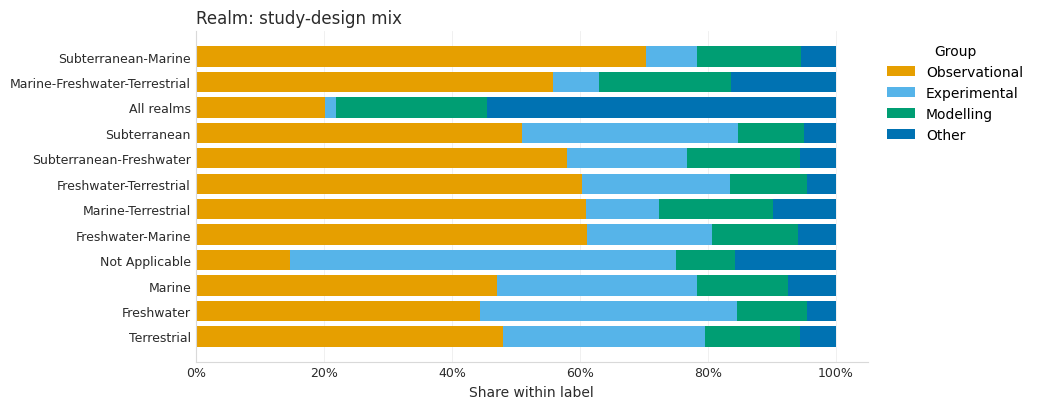

In [60]:
# 5. Realm-specific literature bias.
realm_driver_long, realm_driver_counts, realm_driver_row_shares = multilabel_cross_counts(bio_loss_df, "realm", "driver")
realm_threat_long, realm_threat_counts, realm_threat_row_shares = multilabel_cross_counts(bio_loss_df, "realm", "pred_threat_l0")
realm_study_long, realm_study_counts, realm_study_row_shares = single_vs_multilabel_counts(bio_loss_df, "study_design_group", "realm")
realm_study_counts = realm_study_counts.T
realm_study_row_shares = realm_study_counts.div(realm_study_counts.sum(axis=1), axis=0)

print("Realm x driver counts")
display(realm_driver_counts)
print("Realm x driver shares")
display(pct_table(realm_driver_row_shares.reset_index(), list(realm_driver_row_shares.columns)))
plot_heatmap(realm_driver_row_shares, "Realm x driver: row shares", top_rows=15, top_cols=10)

print("Realm x threat L0 counts")
display(realm_threat_counts)
print("Realm x threat L0 shares")
display(pct_table(realm_threat_row_shares.reset_index(), list(realm_threat_row_shares.columns)))
plot_heatmap(realm_threat_row_shares, "Realm x threat L0: row shares", top_rows=15, top_cols=15)

print("Realm x study design counts")
display(realm_study_counts)
print("Realm x study design shares")
display(pct_table(realm_study_row_shares.reset_index().rename(columns={"index": "realm"}), list(realm_study_row_shares.columns)))
plot_stacked_share_table(realm_study_row_shares, "Realm: study-design mix", top_n=15)


pred_regions: record counts


,label,records,assignments
0,All Regions,68652,68652
1,Americas,67571,67571
2,Asia and the Pacific,61823,61823
3,Europe and Central Asia,43388,43388
4,Africa,18566,18566
5,Antarctica,4573,4573


pred_regions: driver shares


driver,pred_regions,Pollution,Land/sea use change,Climate Change,Direct Exploitation and Resource Extraction,Invasive alien species
0,All Regions,58.4%,12.9%,14.6%,8.0%,6.1%
1,Americas,29.1%,27.4%,18.0%,14.3%,11.2%
2,Asia and the Pacific,27.7%,32.4%,18.4%,14.2%,7.2%
3,Europe and Central Asia,32.0%,25.2%,19.3%,13.1%,10.4%
4,Africa,24.0%,32.3%,15.4%,19.9%,8.4%
5,Antarctica,51.4%,13.0%,20.5%,8.2%,6.9%


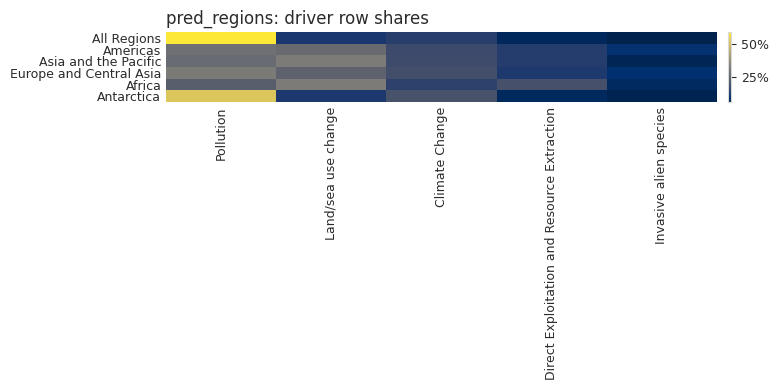

pred_regions: threat L0 shares


pred_threat_l0,pred_regions,Pollution,Climate Change & Severe Weather,Agriculture & Aquaculture,"Invasive & Other Problematic Species, Genes & Diseases",Natural System Modifications,Biological Resource Use,Residential & Commercial Development,Unclear,Energy Production & Mining,Transportation & Service Corridors,Human Intrusions & Disturbance,Other Options
0,All Regions,51.3%,11.9%,5.9%,8.8%,3.4%,3.6%,1.2%,10.2%,1.2%,0.8%,0.7%,1.2%
1,Americas,24.2%,15.6%,11.7%,13.2%,10.4%,8.7%,4.5%,2.9%,3.3%,2.9%,1.6%,0.9%
2,Asia and the Pacific,23.5%,16.0%,13.5%,8.8%,10.3%,8.1%,8.9%,2.4%,3.3%,2.5%,1.7%,0.9%
3,Europe and Central Asia,27.4%,17.1%,10.7%,13.1%,9.8%,7.7%,3.6%,2.7%,2.6%,2.5%,1.8%,1.0%
4,Africa,19.3%,13.5%,18.1%,10.6%,7.2%,14.1%,7.0%,2.7%,3.1%,1.9%,1.7%,1.0%
5,Antarctica,45.1%,17.8%,6.2%,9.3%,4.2%,4.1%,1.2%,7.4%,1.0%,1.1%,1.7%,0.9%


/var/folders/sf/ksfgwr354pl2gjdb_f0yn3vr0000gn/T/ipykernel_47587/1391281643.py:103: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


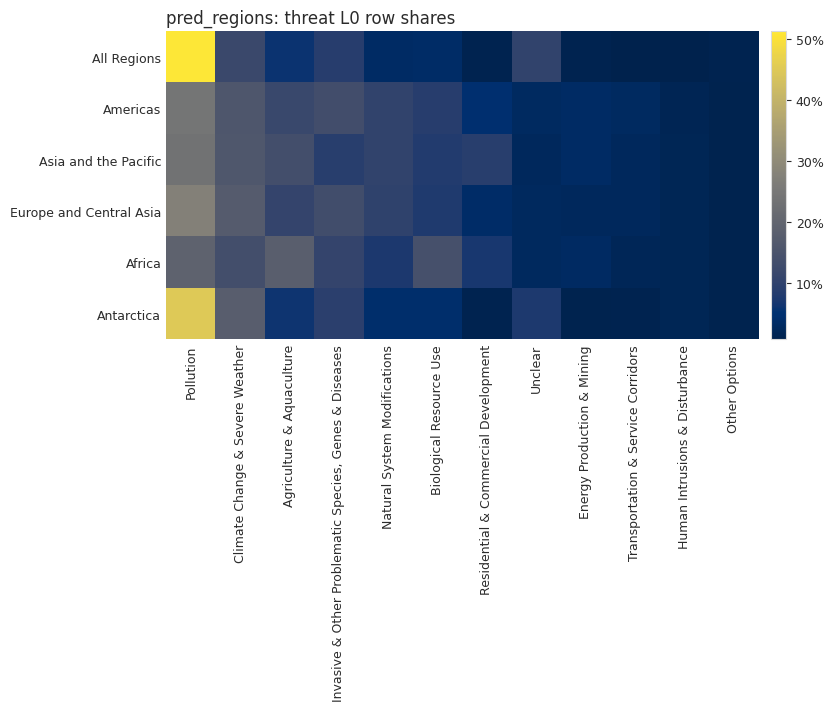

pred_subregions: record counts


,label,records,assignments
0,North America,106026,106026
1,Central and Western Europe,39538,39538
2,North-East Asia,33127,33127
3,South America,22036,22036
4,Oceania,15447,15447
5,South Asia,14505,14505
6,Eastern Europe,14371,14371
7,South-East Asia,11443,11443
8,East Africa and adjacent islands,11355,11355
9,Western Asia,10917,10917


pred_subregions: driver shares


driver,pred_subregions,Pollution,Land/sea use change,Climate Change,Direct Exploitation and Resource Extraction,Invasive alien species
0,North America,45.9%,17.9%,17.0%,10.3%,8.9%
1,Central and Western Europe,34.2%,24.0%,19.1%,12.7%,10.1%
2,North-East Asia,35.1%,29.5%,19.1%,10.6%,5.7%
3,South America,28.7%,32.8%,14.8%,15.2%,8.4%
4,Oceania,28.2%,22.8%,21.1%,14.2%,13.7%
5,South Asia,34.0%,28.4%,17.7%,14.3%,5.6%
6,Eastern Europe,41.3%,20.4%,18.6%,10.9%,8.8%
7,South-East Asia,30.9%,31.7%,15.5%,16.5%,5.5%
8,East Africa and adjacent islands,29.3%,30.9%,16.8%,15.5%,7.5%
9,Western Asia,38.0%,24.2%,18.6%,12.5%,6.7%


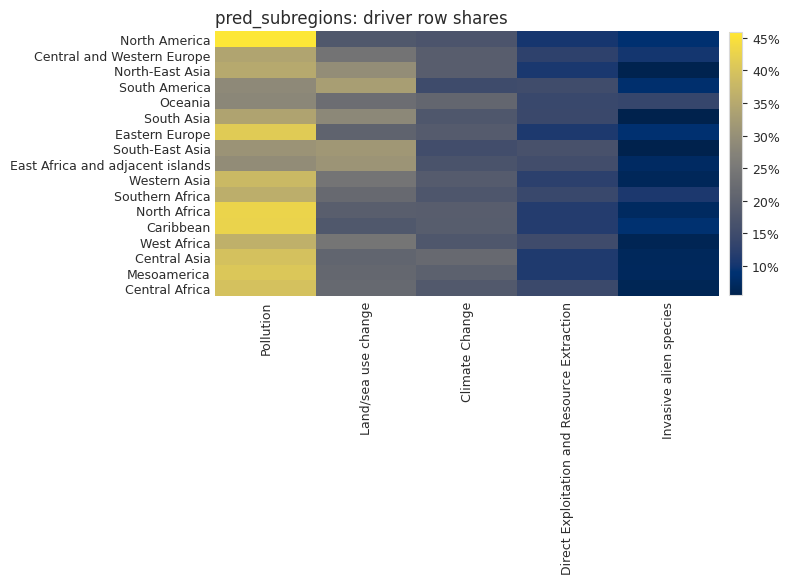

pred_subregions: threat L0 shares


pred_threat_l0,pred_subregions,Pollution,Climate Change & Severe Weather,"Invasive & Other Problematic Species, Genes & Diseases",Agriculture & Aquaculture,Natural System Modifications,Biological Resource Use,Unclear,Residential & Commercial Development,Energy Production & Mining,Transportation & Service Corridors,Human Intrusions & Disturbance,Other Options
0,North America,38.7%,14.5%,11.6%,6.9%,7.1%,5.6%,6.7%,2.9%,2.0%,1.8%,1.1%,1.0%
1,Central and Western Europe,29.1%,16.9%,13.0%,10.4%,9.2%,7.4%,3.4%,3.3%,2.4%,2.2%,1.7%,1.1%
2,North-East Asia,29.8%,16.6%,7.3%,11.7%,9.4%,4.6%,3.5%,8.8%,3.5%,2.2%,1.5%,1.0%
3,South America,24.3%,12.7%,9.8%,18.8%,8.4%,9.7%,2.8%,3.8%,4.3%,2.8%,1.4%,1.1%
4,Oceania,24.0%,18.5%,15.9%,9.4%,10.0%,8.7%,3.7%,3.3%,2.1%,1.9%,1.5%,1.1%
5,South Asia,28.4%,15.4%,7.9%,11.9%,7.5%,9.5%,3.1%,8.9%,2.7%,2.2%,1.7%,0.8%
6,Eastern Europe,35.9%,16.3%,11.2%,8.8%,7.3%,6.3%,4.4%,3.1%,2.4%,2.1%,1.3%,1.0%
7,South-East Asia,25.8%,13.3%,7.7%,17.4%,7.3%,12.1%,3.6%,5.4%,2.8%,2.1%,1.5%,1.0%
8,East Africa and adjacent islands,24.1%,14.5%,9.8%,17.7%,6.3%,11.1%,3.8%,6.5%,2.0%,1.5%,1.6%,1.2%
9,Western Asia,31.6%,16.3%,9.1%,11.0%,7.7%,6.6%,4.6%,6.4%,2.2%,2.0%,1.3%,1.0%


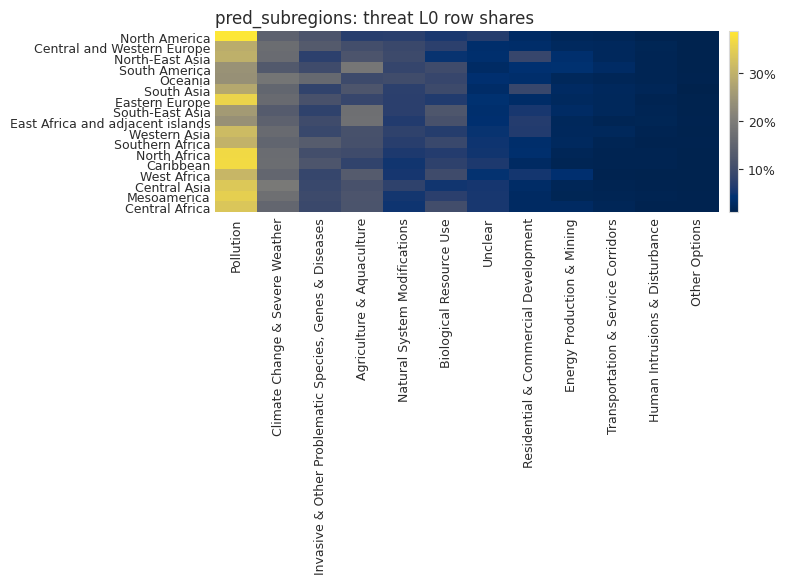

pred_countries: record counts


,label,records,assignments
0,Not Applicable,74590,74590
1,USA,26117,26117
2,CHN,21810,21810
3,Unclear,9291,9291
4,BRA,8941,8941
5,IND,6957,6957
6,CAN,6928,6928
7,AUS,6766,6766
8,ESP,4649,4649
9,ITA,3964,3964


pred_countries: driver shares


driver,pred_countries,Pollution,Land/sea use change,Climate Change,Direct Exploitation and Resource Extraction,Invasive alien species
0,Not Applicable,57.3%,13.1%,15.0%,8.2%,6.3%
1,USA,26.2%,26.1%,19.8%,12.8%,15.1%
2,CHN,30.5%,36.3%,18.6%,10.4%,4.2%
3,Unclear,56.6%,14.9%,14.2%,8.1%,6.2%
4,BRA,26.3%,40.8%,10.4%,15.3%,7.3%
5,IND,30.0%,33.4%,15.7%,15.4%,5.4%
6,CAN,26.2%,23.5%,21.8%,17.1%,11.5%
7,AUS,17.6%,28.2%,23.3%,15.0%,15.9%
8,ESP,24.8%,27.5%,19.9%,15.8%,12.0%
9,ITA,28.5%,25.8%,18.4%,13.5%,13.7%


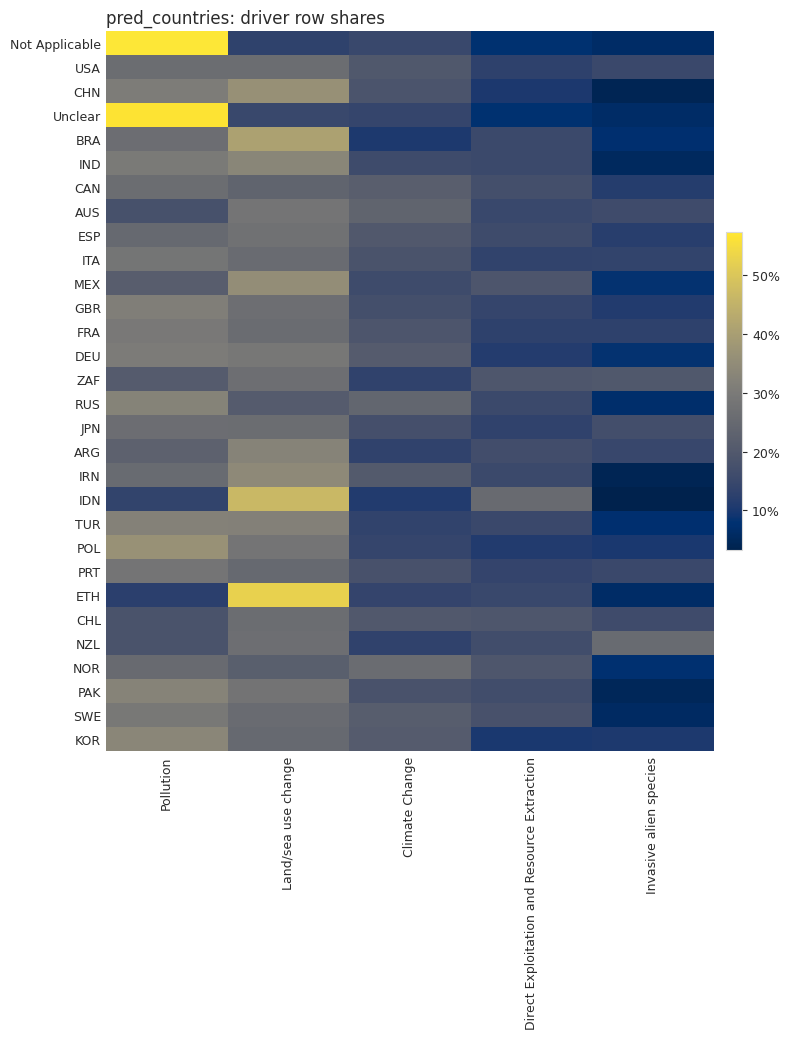

pred_countries: threat L0 shares


pred_threat_l0,pred_countries,Pollution,Climate Change & Severe Weather,Agriculture & Aquaculture,"Invasive & Other Problematic Species, Genes & Diseases",Natural System Modifications,Biological Resource Use,Residential & Commercial Development,Unclear,Energy Production & Mining,Transportation & Service Corridors,Human Intrusions & Disturbance,Other Options
0,Not Applicable,50.3%,12.3%,6.0%,9.0%,3.6%,3.8%,1.3%,9.9%,1.2%,0.8%,0.7%,1.2%
1,USA,21.5%,17.0%,7.5%,17.2%,13.7%,7.0%,5.7%,2.2%,3.0%,3.0%,1.6%,0.7%
2,CHN,26.1%,16.1%,14.4%,5.2%,11.1%,3.7%,11.9%,2.3%,4.3%,2.4%,1.6%,0.9%
3,Unclear,50.4%,11.2%,7.3%,9.0%,4.7%,3.3%,1.3%,8.5%,1.2%,1.0%,1.2%,1.0%
4,BRA,21.9%,8.8%,22.3%,8.4%,10.4%,10.1%,4.9%,1.7%,5.5%,3.6%,1.5%,1.0%
5,IND,25.4%,13.7%,12.8%,7.4%,8.9%,9.6%,11.1%,2.1%,3.8%,2.6%,1.8%,0.8%
6,CAN,22.0%,19.0%,6.6%,14.1%,9.8%,10.8%,3.5%,1.8%,4.9%,4.7%,2.0%,0.8%
7,AUS,14.9%,20.3%,10.0%,17.3%,14.9%,8.6%,4.5%,1.9%,2.1%,2.7%,1.7%,1.1%
8,ESP,21.2%,17.7%,11.9%,14.1%,11.6%,8.8%,3.7%,2.1%,2.8%,2.9%,2.0%,1.3%
9,ITA,23.9%,16.4%,10.5%,15.8%,9.5%,7.7%,5.8%,2.4%,2.0%,2.4%,2.4%,1.2%


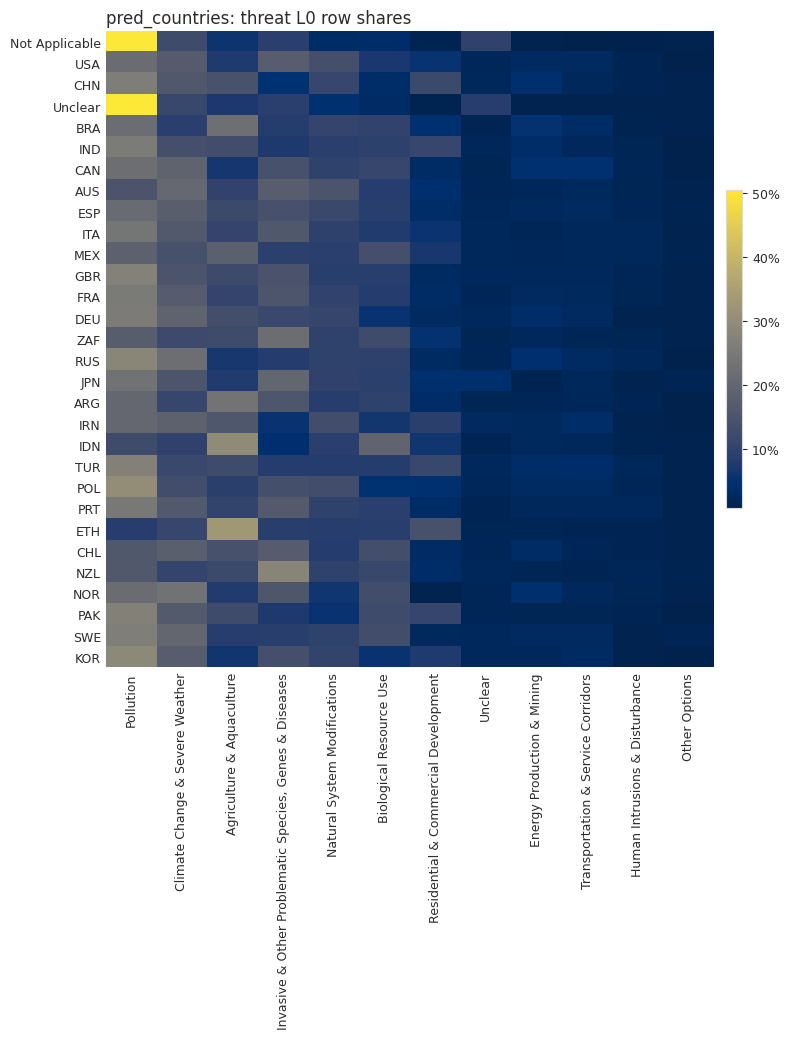

In [61]:
# 6. Geographic bias by regions, subregions, and countries.
geography_bias_tables = {}
for geo_col, top_n in [("pred_regions", 12), ("pred_subregions", 20), ("pred_countries", 30)]:
    geo_counts = label_counts(bio_loss_df, geo_col)
    top_geos = geo_counts.head(top_n)["label"].tolist()
    geography_bias_tables[geo_col] = {"counts": geo_counts}

    print(f"{geo_col}: record counts")
    display(display_top(geo_counts, 60))

    geo_driver_long, geo_driver_counts, geo_driver_row_shares = multilabel_cross_counts(bio_loss_df, geo_col, "driver")
    geo_threat_long, geo_threat_counts, geo_threat_row_shares = multilabel_cross_counts(bio_loss_df, geo_col, "pred_threat_l0")
    geo_driver_row_shares = geo_driver_row_shares.loc[[geo for geo in top_geos if geo in geo_driver_row_shares.index]]
    geo_threat_row_shares = geo_threat_row_shares.loc[[geo for geo in top_geos if geo in geo_threat_row_shares.index]]
    geography_bias_tables[geo_col].update({"driver_shares": geo_driver_row_shares, "threat_shares": geo_threat_row_shares})

    print(f"{geo_col}: driver shares")
    display(pct_table(geo_driver_row_shares.reset_index(), list(geo_driver_row_shares.columns)))
    plot_heatmap(geo_driver_row_shares, f"{geo_col}: driver row shares", top_rows=top_n, top_cols=10)

    print(f"{geo_col}: threat L0 shares")
    display(pct_table(geo_threat_row_shares.reset_index(), list(geo_threat_row_shares.columns)))
    plot_heatmap(geo_threat_row_shares, f"{geo_col}: threat L0 row shares", top_rows=top_n, top_cols=15)


pred_methods_data_collection: counts


,label,records,assignments
0,FieldSurvey,93444,93444
1,LabAssay,82036,82036
2,RemoteSensing,19952,19952
3,GIS_SpatialData,15792,15792
4,LongTermMonitoring,15231,15231
5,Unclear,15070,15070
6,Mesocosm,8621,8621
7,PlotSampling,4652,4652
8,SpecimenRecords_Herbarium_Museum,3072,3072
9,EDNA_Metabarcoding,2611,2611


pred_methods_data_collection: study-design shares


study_design_group,pred_methods_data_collection,Observational,Experimental,Modelling,Other
0,FieldSurvey,76.0%,17.6%,5.9%,0.6%
1,LabAssay,24.4%,73.6%,1.6%,0.4%
2,RemoteSensing,71.4%,1.8%,26.1%,0.8%
3,GIS_SpatialData,59.9%,0.2%,39.1%,0.8%
4,LongTermMonitoring,79.4%,9.8%,10.0%,0.9%
5,Unclear,42.8%,8.6%,30.8%,17.8%
6,Mesocosm,2.4%,96.5%,0.8%,0.3%
7,PlotSampling,29.0%,69.8%,1.2%,0.1%
8,SpecimenRecords_Herbarium_Museum,69.8%,2.7%,23.3%,4.1%
9,EDNA_Metabarcoding,54.8%,42.8%,1.6%,0.8%


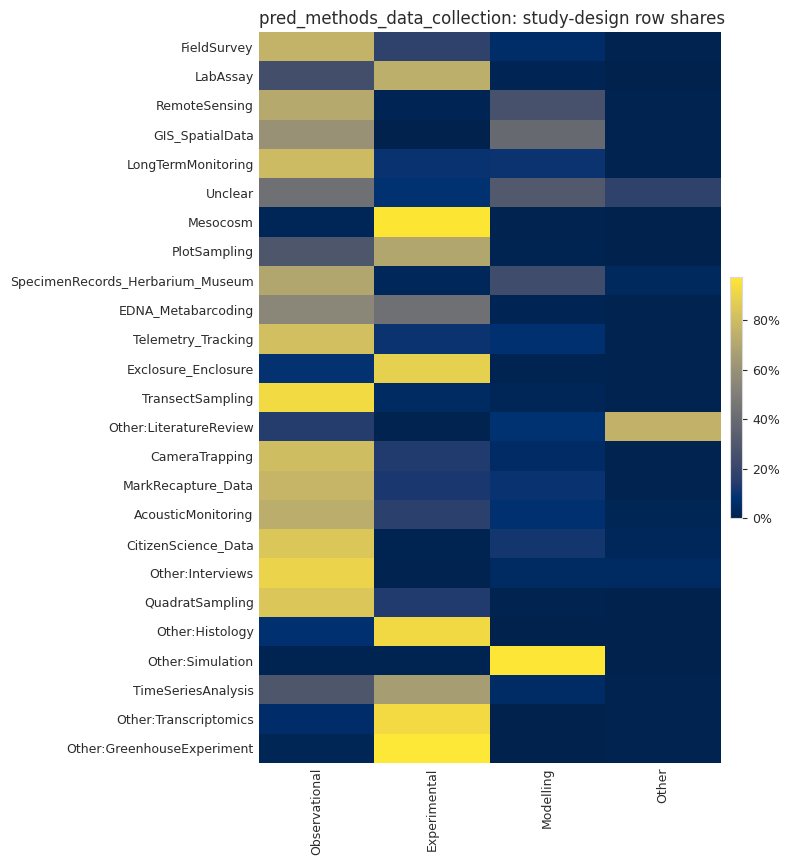

pred_methods_data_collection: realm shares


realm,pred_methods_data_collection,Terrestrial,Freshwater,Marine,Not Applicable,Freshwater-Marine,Marine-Terrestrial,Freshwater-Terrestrial,Subterranean-Freshwater,Subterranean,Marine-Freshwater-Terrestrial,All realms,Subterranean-Marine
0,FieldSurvey,50.5%,25.4%,14.5%,0.5%,4.8%,1.5%,1.5%,0.6%,0.5%,0.1%,0.0%,0.0%
1,LabAssay,35.9%,34.8%,15.2%,9.2%,2.8%,0.5%,0.6%,0.4%,0.5%,0.1%,0.0%,0.0%
2,RemoteSensing,65.9%,16.6%,7.3%,0.4%,3.0%,4.1%,1.7%,0.3%,0.1%,0.4%,0.2%,0.0%
3,GIS_SpatialData,68.4%,17.5%,5.2%,0.5%,2.6%,3.1%,1.4%,0.4%,0.2%,0.4%,0.3%,0.0%
4,LongTermMonitoring,42.0%,30.8%,16.3%,0.8%,5.7%,1.3%,1.3%,0.9%,0.6%,0.2%,0.0%,0.0%
5,Unclear,50.9%,21.1%,15.9%,4.4%,3.3%,1.4%,0.9%,0.4%,0.3%,0.3%,0.9%,0.0%
6,Mesocosm,43.7%,32.0%,17.0%,1.1%,2.8%,0.8%,1.5%,0.3%,0.5%,0.0%,0.0%,0.0%
7,PlotSampling,90.7%,4.0%,2.0%,0.0%,0.6%,0.6%,1.9%,0.0%,0.2%,0.1%,0.0%,0.0%
8,SpecimenRecords_Herbarium_Museum,61.7%,16.2%,15.1%,1.1%,2.5%,0.6%,0.8%,0.2%,1.4%,0.1%,0.4%,0.0%
9,EDNA_Metabarcoding,40.5%,34.4%,13.4%,3.6%,3.7%,0.7%,1.6%,1.0%,1.0%,0.0%,0.1%,0.0%


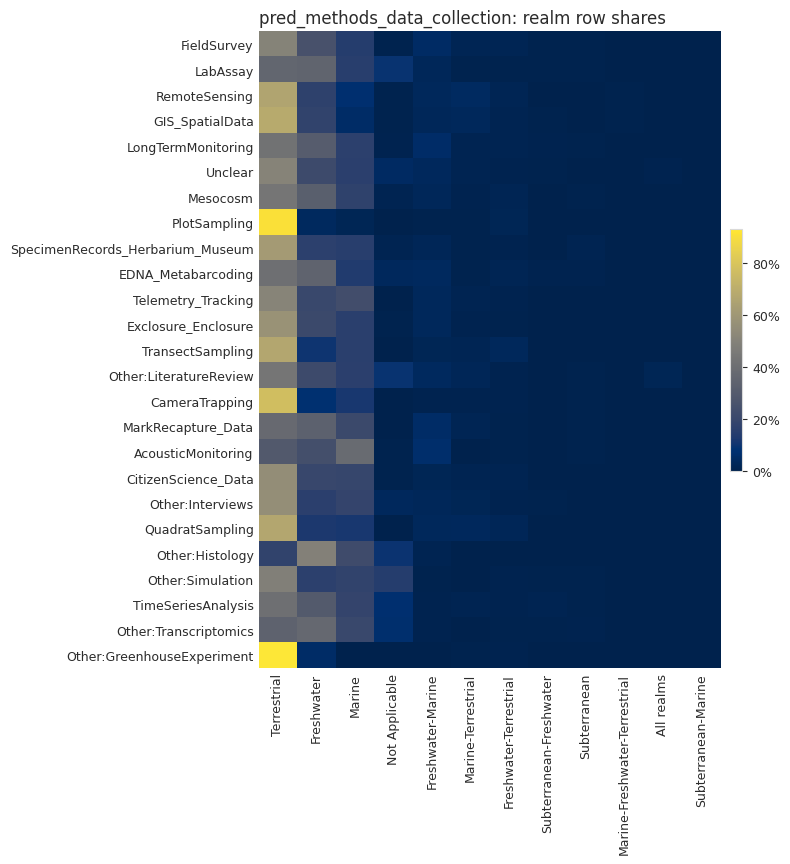

pred_methods_analysis: counts


,label,records,assignments
0,TimeSeriesAnalysis,58318,58318
1,Unclear,44090,44090
2,DiversityMetrics,30915,30915
3,GLM_GLM_MixedEffects,29977,29977
4,SimulationScenarioModelling,24567,24567
5,CommunityComposition_Multivariate,18463,18463
6,SpeciesDistributionModel_SDM,6474,6474
7,SystematicReview_Methods,3147,3147
8,PopulationViabilityAnalysis_PVA,2853,2853
9,Other:StatisticalAnalysis,2753,2753


pred_methods_analysis: study-design shares


study_design_group,pred_methods_analysis,Observational,Experimental,Modelling,Other
0,TimeSeriesAnalysis,69.3%,20.4%,10.0%,0.4%
1,Unclear,38.6%,55.7%,1.6%,4.1%
2,DiversityMetrics,72.4%,24.4%,2.7%,0.5%
3,GLM_GLM_MixedEffects,47.9%,48.5%,3.4%,0.1%
4,SimulationScenarioModelling,9.0%,5.4%,85.0%,0.7%
5,CommunityComposition_Multivariate,71.2%,27.3%,1.1%,0.4%
6,SpeciesDistributionModel_SDM,19.4%,1.0%,79.1%,0.5%
7,SystematicReview_Methods,2.8%,0.2%,0.6%,96.4%
8,PopulationViabilityAnalysis_PVA,31.5%,7.3%,60.5%,0.7%
9,Other:StatisticalAnalysis,16.3%,83.0%,0.5%,0.1%


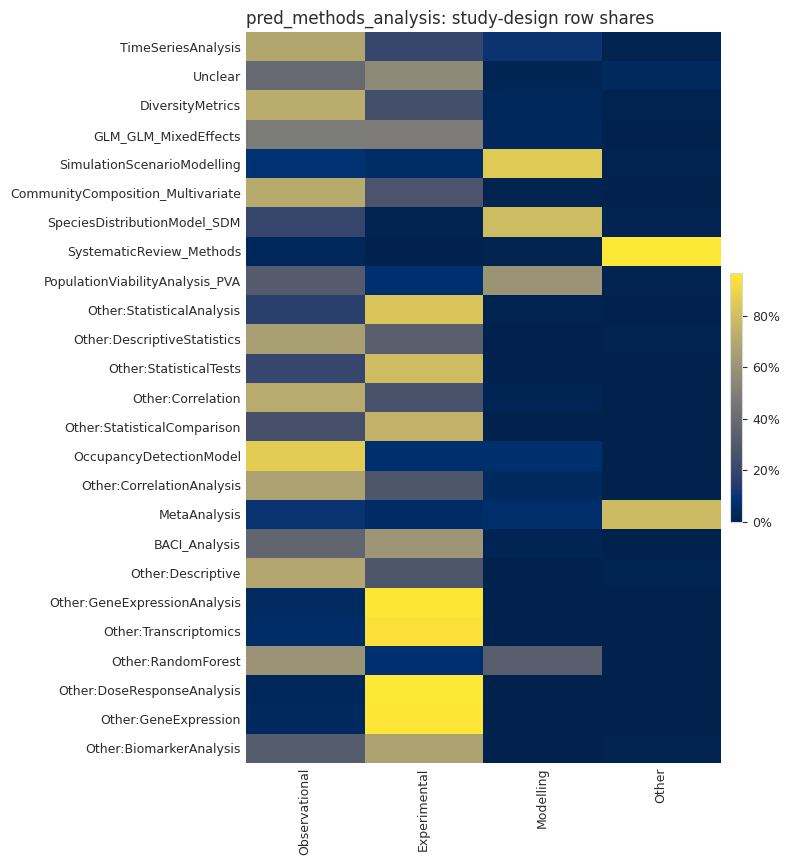

pred_methods_analysis: realm shares


realm,pred_methods_analysis,Terrestrial,Freshwater,Marine,Not Applicable,Freshwater-Marine,Marine-Terrestrial,Freshwater-Terrestrial,Subterranean-Freshwater,Subterranean,All realms,Marine-Freshwater-Terrestrial,Subterranean-Marine
0,TimeSeriesAnalysis,47.6%,26.3%,15.3%,2.2%,4.3%,1.7%,1.2%,0.6%,0.4%,0.1%,0.2%,0.0%
1,Unclear,46.3%,27.0%,15.2%,5.6%,3.0%,1.1%,0.9%,0.3%,0.4%,0.2%,0.1%,0.0%
2,DiversityMetrics,48.9%,28.9%,13.5%,1.4%,3.7%,1.0%,1.6%,0.4%,0.5%,0.1%,0.1%,0.0%
3,GLM_GLM_MixedEffects,56.1%,23.6%,12.1%,3.0%,2.5%,0.8%,1.1%,0.2%,0.3%,0.1%,0.1%,0.0%
4,SimulationScenarioModelling,46.6%,23.7%,17.2%,3.7%,4.1%,1.8%,1.0%,0.8%,0.4%,0.4%,0.3%,0.0%
5,CommunityComposition_Multivariate,43.9%,32.5%,13.4%,1.6%,4.5%,0.9%,1.8%,0.7%,0.6%,0.1%,0.1%,0.0%
6,SpeciesDistributionModel_SDM,71.7%,13.9%,10.2%,0.3%,1.5%,0.8%,1.0%,0.1%,0.2%,0.3%,0.1%,0.0%
7,SystematicReview_Methods,40.2%,20.7%,17.3%,11.5%,3.8%,1.9%,0.9%,0.4%,0.3%,2.5%,0.6%,0.0%
8,PopulationViabilityAnalysis_PVA,45.0%,20.0%,27.9%,2.0%,3.0%,0.9%,0.6%,0.1%,0.3%,0.1%,0.1%,0.0%
9,Other:StatisticalAnalysis,45.7%,29.6%,11.3%,8.7%,2.6%,0.6%,0.9%,0.2%,0.4%,0.0%,0.0%,0.0%


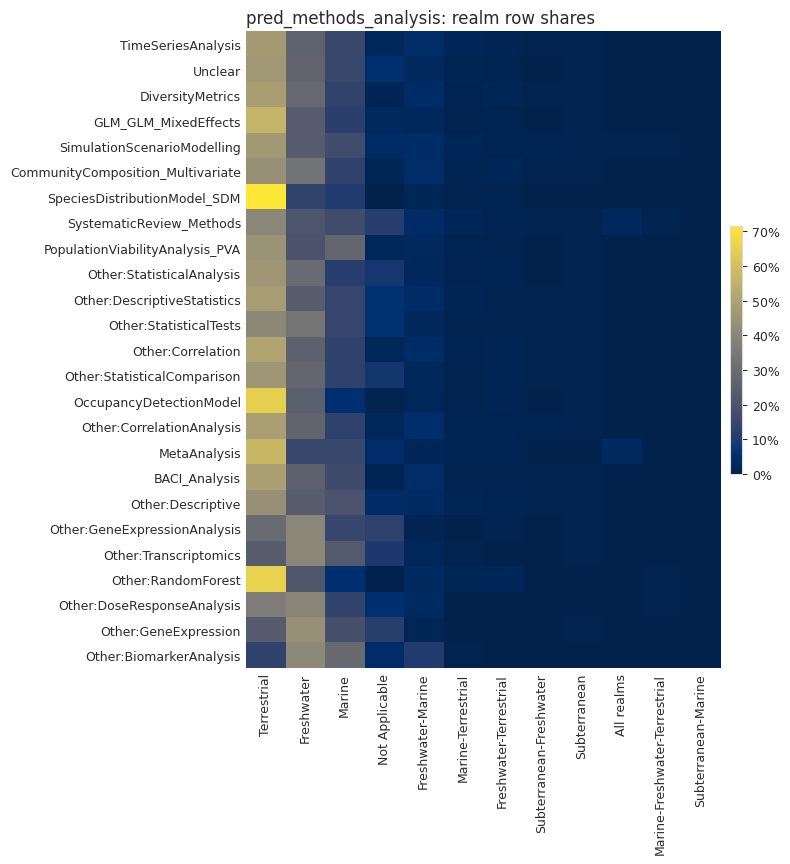

Comparison status by study design


,study_design_group,comparison_status,records,group_records,share_within_group
0,Experimental,Has comparison,75748,86536,87.5%
1,Experimental,No comparison,10788,86536,12.5%
2,Modelling,Has comparison,17047,33993,50.1%
3,Modelling,No comparison,16946,33993,49.9%
4,Observational,Has comparison,71686,116684,61.4%
5,Observational,No comparison,44998,116684,38.6%
6,Other,Has comparison,1206,15868,7.6%
7,Other,No comparison,14662,15868,92.4%


Comparison status by driver


,label,comparison_status,records,label_records,share_within_label
0,Climate Change,Has comparison,32428,53120,61.0%
1,Climate Change,No comparison,20692,53120,39.0%
2,Direct Exploitation and Resource Extraction,Has comparison,22602,40091,56.4%
3,Direct Exploitation and Resource Extraction,No comparison,17489,40091,43.6%
4,Invasive alien species,Has comparison,16173,26397,61.3%
5,Invasive alien species,No comparison,10224,26397,38.7%
6,Land/sea use change,Has comparison,47716,77410,61.6%
7,Land/sea use change,No comparison,29694,77410,38.4%
8,Pollution,Has comparison,80058,113286,70.7%
9,Pollution,No comparison,33228,113286,29.3%


Comparison type counts


,label,records,assignments
0,ControlImpact,57900,57900
1,Other,51338,51338
2,BeforeAfter,23618,23618
3,TreatedUntreated,17881,17881
4,SpatialGradient_NearFar_UpDownstream,15974,15974
5,TimeSeries_Punctuated,11003,11003
6,TimeSeries_ContinuousHighFrequency,5585,5585
7,PresenceAbsence,5486,5486
8,InterruptedTimeSeries,4680,4680
9,BACI,1352,1352


Comparison type x study design shares


study_design_group,pred_comparison_types,Experimental,Observational,Modelling,Other
0,ControlImpact,76.1%,22.4%,1.0%,0.5%
1,Other,42.4%,36.7%,19.7%,1.2%
2,BeforeAfter,26.1%,56.9%,16.3%,0.7%
3,TreatedUntreated,83.2%,15.4%,1.1%,0.3%
4,SpatialGradient_NearFar_UpDownstream,6.3%,89.7%,3.6%,0.4%
5,TimeSeries_Punctuated,11.1%,76.2%,12.3%,0.4%
6,TimeSeries_ContinuousHighFrequency,12.1%,69.6%,17.8%,0.5%
7,PresenceAbsence,17.2%,76.0%,5.7%,1.1%
8,InterruptedTimeSeries,9.4%,81.8%,8.3%,0.5%
9,BACI,56.4%,41.1%,1.9%,0.6%


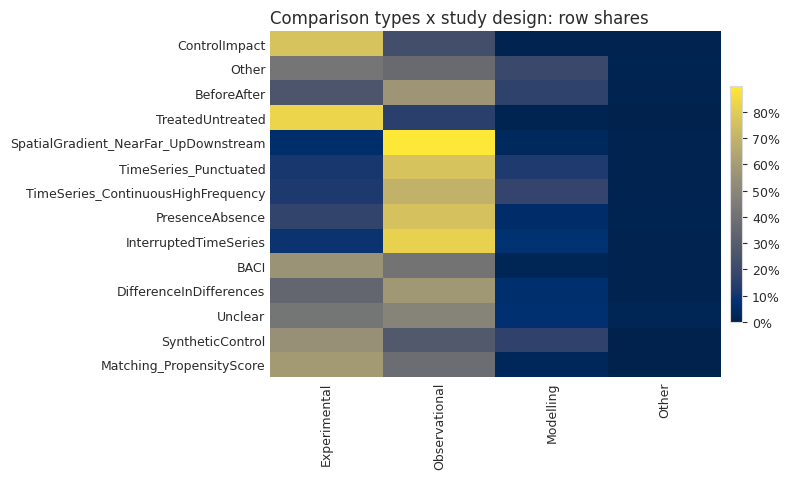

In [62]:
# 7-8. Methods/data-collection bias and comparison-design strength.
method_bias_tables = {}
for method_col in ["pred_methods_data_collection", "pred_methods_analysis"]:
    method_counts = label_counts(bio_loss_df, method_col)
    method_study_long, method_study_counts, method_study_row_shares = multilabel_cross_counts(bio_loss_df, method_col, "study_design_group")
    method_realm_long, method_realm_counts, method_realm_row_shares = multilabel_cross_counts(bio_loss_df, method_col, "realm")
    top_methods = method_counts.head(25)["label"].tolist()
    method_study_row_shares = method_study_row_shares.loc[[method for method in top_methods if method in method_study_row_shares.index]]
    method_realm_row_shares = method_realm_row_shares.loc[[method for method in top_methods if method in method_realm_row_shares.index]]
    method_bias_tables[method_col] = {"counts": method_counts, "study_shares": method_study_row_shares, "realm_shares": method_realm_row_shares}

    print(f"{method_col}: counts")
    display(display_top(method_counts, 60))
    print(f"{method_col}: study-design shares")
    display(pct_table(method_study_row_shares.reset_index(), list(method_study_row_shares.columns)))
    plot_heatmap(method_study_row_shares, f"{method_col}: study-design row shares", top_rows=25, top_cols=8)
    print(f"{method_col}: realm shares")
    display(pct_table(method_realm_row_shares.reset_index(), list(method_realm_row_shares.columns)))
    plot_heatmap(method_realm_row_shares, f"{method_col}: realm row shares", top_rows=25, top_cols=12)

comparison_df = bio_loss_df.copy()
comparison_df["comparison_status"] = comparison_df["pred_has_comparison"].map(lambda value: "Has comparison" if str(value).strip().lower() == "true" else "No comparison")
comparison_by_study = (
    comparison_df.groupby(["study_design_group", "comparison_status"], observed=True)["UT"]
    .nunique()
    .rename("records")
    .reset_index()
)
comparison_by_study["group_records"] = comparison_by_study.groupby("study_design_group", observed=True)["records"].transform("sum")
comparison_by_study["share_within_group"] = comparison_by_study["records"] / comparison_by_study["group_records"]

comparison_by_driver = exploded_label_with_cols(comparison_df, "driver", ["comparison_status"])
comparison_by_driver = (
    comparison_by_driver.groupby(["label", "comparison_status"], observed=True)["UT"]
    .nunique()
    .rename("records")
    .reset_index()
)
comparison_by_driver["label_records"] = comparison_by_driver.groupby("label", observed=True)["records"].transform("sum")
comparison_by_driver["share_within_label"] = comparison_by_driver["records"] / comparison_by_driver["label_records"]

comparison_type_counts = label_counts(comparison_df, "pred_comparison_types")
comparison_type_study_long, comparison_type_study_counts, comparison_type_study_shares = multilabel_cross_counts(comparison_df, "pred_comparison_types", "study_design_group")

print("Comparison status by study design")
display(pct_table(comparison_by_study, ["share_within_group"]))

print("Comparison status by driver")
display(pct_table(comparison_by_driver, ["share_within_label"]))

print("Comparison type counts")
display(comparison_type_counts)

print("Comparison type x study design shares")
display(pct_table(comparison_type_study_shares.reset_index(), list(comparison_type_study_shares.columns)))
plot_heatmap(comparison_type_study_shares, "Comparison types x study design: row shares", top_rows=25, top_cols=8)


S2 direction counts in full eligible corpus


,s2_dir_group,records,share
0,negative,253081,41.8%
1,mixed,141267,23.3%
2,positive,112684,18.6%
3,unclear,98167,16.2%


S2 direction counts by year


s2_dir_group,mixed,negative,positive,unclear
publication_year,,,,
2000,1377,2530,877,980
2001,1569,2665,984,1055
2002,1611,2879,1038,1105
2003,1817,3146,1183,1251
2004,1913,3398,1272,1395
2005,2117,3809,1348,1447
2006,2372,4375,1599,1704
2007,2593,4695,1755,1893
2008,2839,5351,1933,2077


S2 direction shares by year


s2_dir_group,publication_year,mixed,negative,positive,unclear
0,2000,23.9%,43.9%,15.2%,17.0%
1,2001,25.0%,42.5%,15.7%,16.8%
2,2002,24.3%,43.4%,15.6%,16.7%
3,2003,24.6%,42.5%,16.0%,16.9%
4,2004,24.0%,42.6%,15.9%,17.5%
5,2005,24.3%,43.7%,15.5%,16.6%
6,2006,23.6%,43.5%,15.9%,17.0%
7,2007,23.7%,42.9%,16.0%,17.3%
8,2008,23.3%,43.9%,15.8%,17.0%
9,2009,23.0%,43.9%,15.7%,17.4%


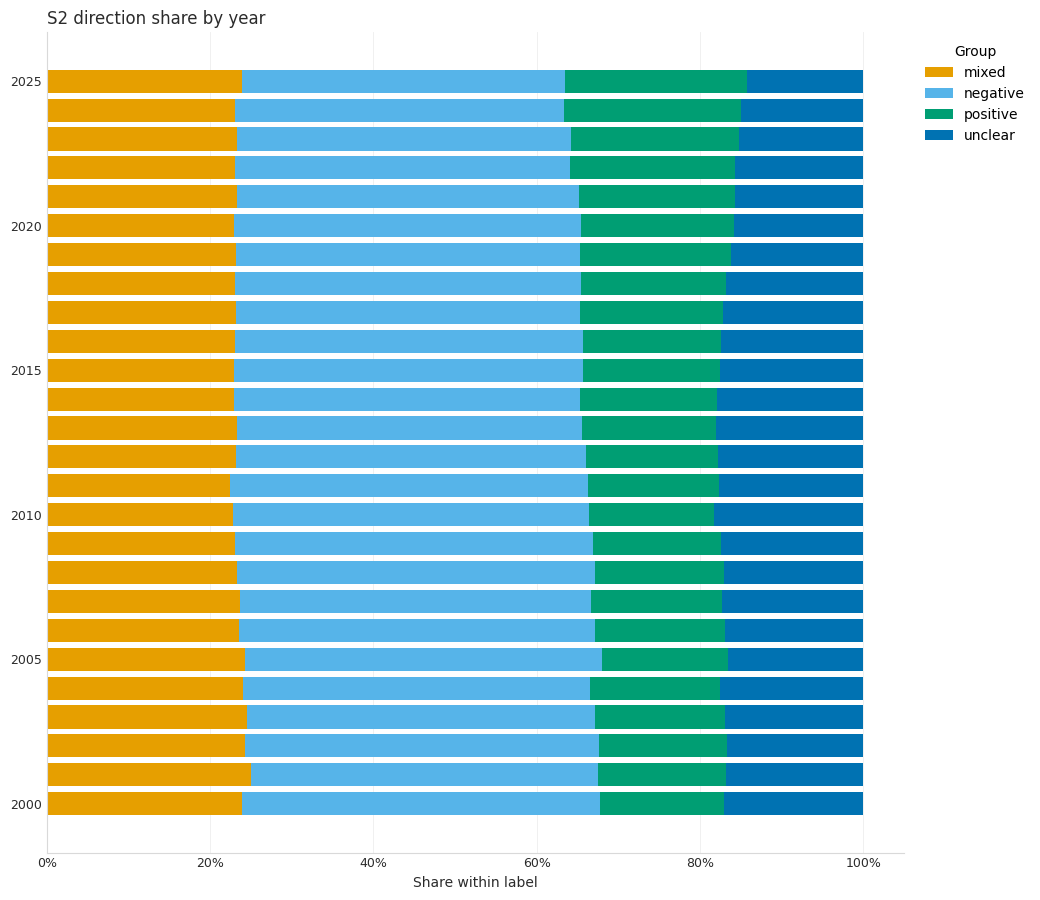

Negative share by driver in full eligible corpus


,label,s2_dir_group,records,label_records,share_within_label
0,Pollution,negative,113286,250827,45.2%
1,Direct Exploitation and Resource Extraction,negative,40091,95138,42.1%
2,Invasive alien species,negative,26397,67451,39.1%
3,Land/sea use change,negative,77410,200347,38.6%
4,Climate Change,negative,53120,148545,35.8%


Negative share by threat L0 in full eligible corpus


,label,s2_dir_group,records,label_records,share_within_label
0,Residential & Commercial Development,negative,16205,29241,55.4%
1,Transportation & Service Corridors,negative,7054,12852,54.9%
2,Energy Production & Mining,negative,8728,16874,51.7%
3,Pollution,negative,99479,194253,51.2%
4,Biological Resource Use,negative,24935,49136,50.7%
5,Human Intrusions & Disturbance,negative,4779,10156,47.1%
6,"Invasive & Other Problematic Species, Genes & ...",negative,35135,77615,45.3%
7,Other Options,negative,3276,7246,45.2%
8,Natural System Modifications,negative,27596,62464,44.2%
9,Agriculture & Aquaculture,negative,36305,85838,42.3%


Evidence link by S2 direction


,s2_dir_group,s4_link_group,records,dir_records,share_within_direction
0,mixed,assessed,4413,141267,3.1%
1,mixed,direct_primary_evidence,97877,141267,69.3%
2,mixed,modelled,13090,141267,9.3%
3,mixed,plausibly_implied,18557,141267,13.1%
4,mixed,projected,3146,141267,2.2%
5,mixed,unclear,4184,141267,3.0%
6,negative,assessed,18429,253081,7.3%
7,negative,direct_primary_evidence,143187,253081,56.6%
8,negative,modelled,21643,253081,8.6%
9,negative,plausibly_implied,57044,253081,22.5%


In [63]:
# 9. Direction / evidence-confidence checks against the full eligible corpus.
direction_df = corpus_df.copy()
direction_df["s2_dir_group"] = direction_df["s2_dir"].fillna("missing").astype("string").str.strip().str.lower().replace({"": "missing"})
direction_df["s4_link_group"] = direction_df["s4_link"].fillna("missing").astype("string").str.strip().str.lower().replace({"": "missing"})

direction_counts = direction_df["s2_dir_group"].value_counts().rename_axis("s2_dir_group").reset_index(name="records")
direction_counts["share"] = direction_counts["records"] / len(direction_df)

direction_year_counts = single_category_year_counts(direction_df, "s2_dir_group")
direction_year_totals = year_totals(direction_df)
direction_year_counts = direction_year_counts.merge(direction_year_totals, on="publication_year", how="left")
direction_year_counts["share_of_year_records"] = direction_year_counts["records"] / direction_year_counts["year_records"]
direction_year_pivot = direction_year_counts.pivot_table(index="publication_year", columns="s2_dir_group", values="records", fill_value=0, aggfunc="sum")
direction_year_share_pivot = direction_year_counts.pivot_table(index="publication_year", columns="s2_dir_group", values="share_of_year_records", fill_value=0, aggfunc="sum")

def negative_share_by_label(df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    exploded = exploded_label_with_cols(df, label_col, ["s2_dir_group", "s4_link_group"])
    out = (
        exploded.groupby(["label", "s2_dir_group"], observed=True)["UT"]
        .nunique()
        .rename("records")
        .reset_index()
    )
    label_totals = exploded.groupby("label", observed=True)["UT"].nunique().rename("label_records")
    out = out.merge(label_totals, on="label", how="left")
    out["share_within_label"] = out["records"] / out["label_records"]
    negative = out.loc[out["s2_dir_group"].eq("negative")].sort_values("share_within_label", ascending=False, ignore_index=True)
    return negative

negative_driver_share = negative_share_by_label(direction_df, "driver")
negative_threat_share = negative_share_by_label(direction_df, "pred_threat_l0")
link_by_direction = (
    direction_df.groupby(["s2_dir_group", "s4_link_group"], observed=True)["UT"]
    .nunique()
    .rename("records")
    .reset_index()
)
link_by_direction["dir_records"] = link_by_direction.groupby("s2_dir_group", observed=True)["records"].transform("sum")
link_by_direction["share_within_direction"] = link_by_direction["records"] / link_by_direction["dir_records"]

print("S2 direction counts in full eligible corpus")
display(pct_table(direction_counts, ["share"]))

print("S2 direction counts by year")
display(direction_year_pivot)

print("S2 direction shares by year")
display(pct_table(direction_year_share_pivot.reset_index(), list(direction_year_share_pivot.columns)))
plot_stacked_share_table(direction_year_share_pivot, "S2 direction share by year", top_n=30)

print("Negative share by driver in full eligible corpus")
display(pct_table(negative_driver_share, ["share_within_label"]))

print("Negative share by threat L0 in full eligible corpus")
display(pct_table(negative_threat_share, ["share_within_label"]))

print("Evidence link by S2 direction")
display(pct_table(link_by_direction, ["share_within_direction"]))
